# Deep Learning Assignment 2
#### By: Logan Justin Gunawan (S4096363)

## The Task:

I have built the company Litmus pty with my friend. Litmus pty runs studies on the deconstruction and analysis of memes and how they use certain psychological techniques to elicit a response from a viewer. Previously, we have done all of this analysis by hand, however, we would like to expand our reach by creating a model which automatically detects, what psychological techniques a meme uses, as well as what part of the meme specifically uses each technique. We have 22 possible techniques (listed under 'techniques_list_task3.txt') to choose from, but a meme can also utilise none of those techniques. Additionally, 2 of the techniques are not applicable for this task as they are only used for Image-based memes, whereas we focus on the extracted text of a meme. We will remove the 2 inapplicable techniques, "Transfer" and "Appeal to (Strong) emotions" from our list of techniques.

## Loading Libraries

In [302]:
import torch
import torch.nn as nn   
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [303]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import re, os, math
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, multilabel_confusion_matrix
import copy
from IPython.display import clear_output
from peft import LoraConfig, get_peft_model, TaskType

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## The Data

I first load the data which is provided to me. The data has already been pre-split into a train, dev and test sets so no further splitting is required.

In [304]:
LABELS = [  "Appeal to authority",
            "Appeal to fear/prejudice",
            "Black-and-white Fallacy/Dictatorship",
            "Causal Oversimplification",
            "Doubt",
            "Exaggeration/Minimisation",
            "Flag-waving",
            "Glittering generalities (Virtue)",
            "Loaded Language",
            "Misrepresentation of Someone's Position (Straw Man)",
            "Name calling/Labeling",
            "Obfuscation, Intentional vagueness, Confusion",
            "Presenting Irrelevant Data (Red Herring)",
            "Reductio ad hitlerum",
            "Repetition",
            "Slogans",
            "Smears",
            "Thought-terminating cliché",
            "Whataboutism",
            "Bandwagon"
]

# Importing all the data
dev_set_task1 = pd.read_json("data_2026_A2/data/dev_set_task1.txt")
dev_set_task2 = pd.read_json("data_2026_A2/data/dev_set_task2.txt")
test_set_task1 = pd.read_json("data_2026_A2/data/test_set_task1.txt")
test_set_task2 = pd.read_json("data_2026_A2/data/test_set_task2.txt")
train_set_task1 = pd.read_json("data_2026_A2/data/training_set_task1.txt")
train_set_task2 = pd.read_json("data_2026_A2/data/training_set_task2.txt")

print(f"Task 1 Train Dataset Length: {len(train_set_task1)}")
print(f"Task 2 Train Dataset Length: {len(train_set_task2)}")
print(f"Task 1 Test Dataset Length: {len(test_set_task1)}")
print(f"Task 2 Test Dataset Length: {len(test_set_task2)}")
print(f"Task 1 Dev Dataset Length: {len(dev_set_task1)}")
print(f"Task 2 Dev Dataset Length: {len(dev_set_task2)}")

train_set_task1.head()

Task 1 Train Dataset Length: 688
Task 2 Train Dataset Length: 688
Task 1 Test Dataset Length: 200
Task 2 Test Dataset Length: 200
Task 1 Dev Dataset Length: 63
Task 2 Dev Dataset Length: 63


,id,labels,text
0,128,[Black-and-white Fallacy/Dictatorship],THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n
1,189,[],This is not an accident!
2,96,"[Loaded Language, Name calling/Labeling, Sloga...",SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...
3,154,"[Causal Oversimplification, Loaded Language, N...",PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...
4,15,[],WHO TRUMP REPRESENTS\n\nWHO DEMOCRATS REPRESENT\n


I can then view the distribution of each label, to see how common they are within the dataset. The following pie chart reveals the most commonly used labels being "Loaded Language", "Name Calling / Labeling" and "Smears" which occupy a large portion of the data, whereas minority labels such as Red Herring, Obfuscation, etc barely appear. I will need to take into consideration these label instability later when creating my models. The fact that there are labels with only ~1-4 positive samples in the training data is especially distressing, as it might cause the model to be completely unable to learn patterns for these labels. I will have to remember this information when evaluating my models later.

Text(0.5, 1.0, 'Label Distribution')

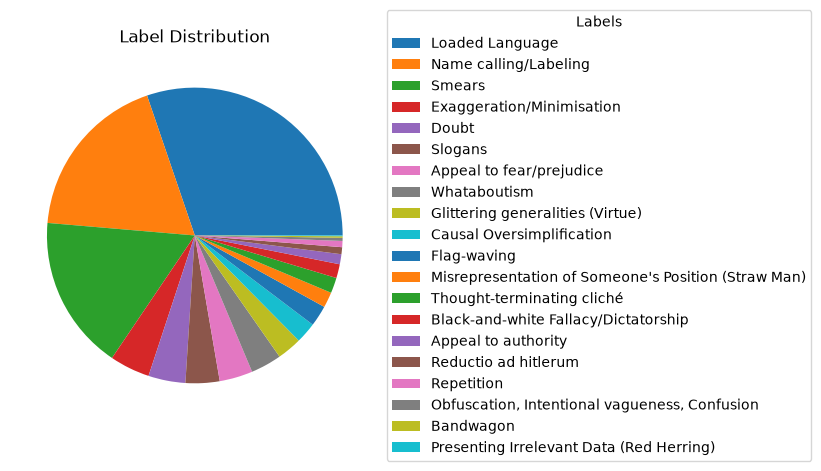

In [305]:
# Generate a Pie Chart to view label distribution.
label_counts = Counter(
    label
    for labels in train_set_task1["labels"]
    for label in labels
)

label_counts_df = pd.DataFrame(label_counts.items(), columns = ["Label", "Count"]).sort_values(by = "Count", ascending = False)

wedges, _ = plt.pie(label_counts_df["Count"].values)

plt.legend(wedges,
           label_counts_df["Label"].values,
           title="Labels",
           bbox_to_anchor=(1, 0.5),
           loc="center left")

plt.title("Label Distribution")

In [306]:
# View the actual counts for each label
label_counts.most_common()

[('Loaded Language', 358),
 ('Name calling/Labeling', 218),
 ('Smears', 200),
 ('Exaggeration/Minimisation', 52),
 ('Doubt', 48),
 ('Slogans', 44),
 ('Appeal to fear/prejudice', 43),
 ('Whataboutism', 40),
 ('Glittering generalities (Virtue)', 32),
 ('Causal Oversimplification', 27),
 ('Flag-waving', 27),
 ("Misrepresentation of Someone's Position (Straw Man)", 20),
 ('Thought-terminating cliché', 20),
 ('Black-and-white Fallacy/Dictatorship', 18),
 ('Appeal to authority', 13),
 ('Reductio ad hitlerum', 9),
 ('Repetition', 8),
 ('Obfuscation, Intentional vagueness, Confusion', 4),
 ('Bandwagon', 2),
 ('Presenting Irrelevant Data (Red Herring)', 1)]

### Label Encoding

I need to transform my labels from a string into a one hot encoded vector representation. The following code allows me to do that.

In [307]:
# Encode the labels as a One Hot Encoded vector representation
label_to_idx = {label : i for i, label in enumerate(LABELS)}

def encode_labels(labels):
    encoded = [0] * len(LABELS)
    for label in labels:
        encoded[label_to_idx[label]] = 1

    return torch.tensor(encoded, dtype=torch.float32)

train_set_task1["label_encoded"] = train_set_task1["labels"].apply(encode_labels)
test_set_task1["label_encoded"] = test_set_task1["labels"].apply(encode_labels)
dev_set_task1["label_encoded"] = dev_set_task1["labels"].apply(encode_labels)

train_set_task1.head()

,id,labels,text,label_encoded
0,128,[Black-and-white Fallacy/Dictatorship],THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n,"[tensor(0.), tensor(0.), tensor(1.), tensor(0...."
1,189,[],This is not an accident!,"[tensor(0.), tensor(0.), tensor(0.), tensor(0...."
2,96,"[Loaded Language, Name calling/Labeling, Sloga...",SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...,"[tensor(0.), tensor(0.), tensor(0.), tensor(0...."
3,154,"[Causal Oversimplification, Loaded Language, N...",PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...,"[tensor(0.), tensor(0.), tensor(0.), tensor(1...."
4,15,[],WHO TRUMP REPRESENTS\n\nWHO DEMOCRATS REPRESENT\n,"[tensor(0.), tensor(0.), tensor(0.), tensor(0...."


## Utilities

Here I create some general utility functions which will be used across my tasks. 

#### Generating Label Weights

I create a label weight map such that I can use it later in my loss calculations in order to solve the problem of label inequality. For my baseline, I use inverse frequency class weighting, it gives values with low label counts higher weights, such that the model should prioritize labelling minority labels correctly. 

Viewing the generated label weights for task 1, I notice several potential issues, which I will explain and improve on further on in model experiments.

In [308]:
# Generating Label Weights
task1_label_counts = Counter(label
                             for labels in train_set_task1["labels"]
                             for label in labels)

total = len(train_set_task1)
total_labels = len(LABELS)

task1_label_weights = torch.tensor(
    [
    (total - task1_label_counts[label]) / (task1_label_counts[label])
    if task1_label_counts[label] > 0 else 1
    for label in LABELS
    ]
).to(device)

print('Label weights for Task 1:')
for i, label in enumerate(LABELS):
    print(
        f"{label:<55} "
        f"count={task1_label_counts[label]:>3} "
        f"weight={task1_label_weights[i].item():.2f}"
    )

Label weights for Task 1:
Appeal to authority                                     count= 13 weight=51.92
Appeal to fear/prejudice                                count= 43 weight=15.00
Black-and-white Fallacy/Dictatorship                    count= 18 weight=37.22
Causal Oversimplification                               count= 27 weight=24.48
Doubt                                                   count= 48 weight=13.33
Exaggeration/Minimisation                               count= 52 weight=12.23
Flag-waving                                             count= 27 weight=24.48
Glittering generalities (Virtue)                        count= 32 weight=20.50
Loaded Language                                         count=358 weight=0.92
Misrepresentation of Someone's Position (Straw Man)     count= 20 weight=33.40
Name calling/Labeling                                   count=218 weight=2.16
Obfuscation, Intentional vagueness, Confusion           count=  4 weight=171.00
Presenting Irrelevant Data 

#### Training Utilities (Adapted from Labs)

Here I adapt some utility functions straight from the labs so that they will fit the multi-label classification problem that we have. 

In [309]:
def train_one_epoch(model, loader, optimizer, criterion, tokenizer_mode=False):
    # Function adapted from Week 8 Labs.
    """
    Trains one epoch of the model using data from the dataloader.
    Calculates loss as according to the criterion and does backpropogation.
    Returns the mean loss for this epoch
    """
    
    model.train()
    total_loss, total = 0.0, 0
    for batch in loader:
        if tokenizer_mode:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=y)
            logits = outputs.logits
            loss = criterion(logits, y)
        else:
            x, y, lengths = batch
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * y.numel()
        total += y.numel()
    return total_loss / total


def evaluate_model(model, loader, criterion, tokenizer_mode=False):
    # Function adapted from Week 8 labs
    """
    Evaluation function used to calculate validation loss during training.
    """
    
    model.eval()
    total_loss, total = 0.0, 0
    with torch.inference_mode():
        for batch in loader:
            if tokenizer_mode:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                y = batch['labels'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=y)
                logits = outputs.logits
                loss = criterion(logits, y)
            else:
                x, y, lengths = batch
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
            
            total_loss += loss.item() * y.numel()
            total += y.numel()
    return total_loss / total


def run_experiment(model, optimizer, criterion, train_loader, val_loader,
                   epochs=10, name='Model', tokenizer_mode=False, load_best_model=True):
    # Function adapted from Week 8 labs.
    """
    Main training loop.
    Trains a model across 'epochs' epochs.
    If we want to, we can save the best performing model as according to the validation loss (helps with overfitting).
    Returns a dictionary which contains our training and validation loss across epochs.
    """
    
    history = {'train_loss': [], 'val_loss': []}
    best_model = None
    best_loss = 999999
    
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, tokenizer_mode)
        val_loss = evaluate_model(model, val_loader, criterion, tokenizer_mode)
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if (epoch + 1) % max(1, epochs // 5) == 0 or epoch == 0:
            print(f'  [{name}] Epoch {epoch+1}/{epochs} — '
                  f'Train: {train_loss:.4f} | Val: {val_loss:.4f}')
    
    if load_best_model and best_model is not None:
        model.load_state_dict(best_model)
    
    return history


def plot_experiments(results, models = ["all"], show_train=True, show_val=True):
    # Function adapted from Week 8 labs.
    """
    Plots the loss curve of all models in results.
    """
    fig, ax = plt.subplots()
    
    if "all" in models:
        for name, hist in results.items():
            epochs = range(1, len(hist['train_loss']) + 1)
            if show_train:
                ax.plot(epochs, hist['train_loss'], label=f'{name} (Train)', marker='o', markersize=3)
            if show_val:
                ax.plot(epochs, hist['val_loss'], label=f'{name} (Val)', linestyle='--', marker='x', markersize=3)
    else:
        for name in models:
            hist = results[name]
            epochs = range(1, len(hist['train_loss']) + 1)
            if show_train:
                ax.plot(epochs, hist['train_loss'], label=f'{name} (Train)', marker='o', markersize=3)
            if show_val:
                ax.plot(epochs, hist['val_loss'], label=f'{name} (Val)', linestyle='--', marker='x', markersize=3)
    ax.set_xlabel('Epoch'); ax.set_ylabel("Loss"); ax.set_title("Loss")
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

I also create a custom evaluation function get_evaluation() which I will be using to evaluate my task 1 models. It uses creates a classification report of the model's predictions vs ground truth giving per-class precision, recall, f1-score and accuracy counts, as well as overall micro and macro averaged values for those values. Then it creates a multi-label confusion matrix and returns both of them as a tuple. This will help get better insight at how the model is predicting on each label.

In [310]:
def get_evaluation(model, val_loader, name, tokenizer_mode = False, prob_thresholds = None):
    """
    Custom model-specific evaluation method for Task 1 models.
    Calculates the model's evaluation metrics across per-label evaluation, micro, macro and weighted.
    Creates n confusion matrices where n corresponds to the number of labels.
    """
    model.eval()
    val_predictions = []
    val_true = []
    total_tp, total_tn, total_fp, total_fn = 0, 0, 0, 0
    
    # Use custom probability thresholds for each label if we pass it in.
    # Otherwise use a default value of 0.5 as a prob threshold for every label.
    if prob_thresholds != None:
        prob_thresholds = torch.tensor(prob_thresholds).to(device)
    else:
        prob_thresholds = torch.full((20,), 0.5).to(device)
    
    with torch.inference_mode():
        # Generates the YTrue and YPred for our model.
        for batch in val_loader:
            if tokenizer_mode:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                y = batch['labels'].to(device)
                outputs = model(input_ids=input_ids, 
                                attention_mask=attention_mask, 
                                labels=y)
                logits = outputs.logits
            else:
                x, y, lengths = batch
                x, y = x.to(device), y.to(device)
                logits = model(x)
            
            probabilities = torch.sigmoid(logits)
            prediction = (probabilities >= prob_thresholds).float()
            
            val_predictions.append(prediction)
            val_true.append(y)
    
    val_predictions = torch.cat(val_predictions, dim=0).cpu().numpy()
    val_true = torch.cat(val_true, dim=0).cpu().numpy()
    
    # Generate the confusion matrix
    matrix = multilabel_confusion_matrix(val_true, 
                                         val_predictions)
    
    # Generate the classification report
    report = classification_report(val_true, 
                                    val_predictions, 
                                    target_names=LABELS, 
                                    output_dict = True)

    # Modify the current matrix and report to plot each matrix as a seperate plot on a 5x5 grid.
    # And add accuracy as a metric for the report.    
    fig, ax = plt.subplots(4, 5, figsize = (10,10))

    for i, label in enumerate(LABELS):
        current_ax = ax[i//5][i%5]
        current_row = report[label]
        
        cf = ConfusionMatrixDisplay(matrix[i])
        cf.plot(ax = current_ax,cmap='Blues', colorbar = False)
        current_ax.set_title(label[:20], fontsize=10)
        
        tn, fp, fn, tp = matrix[i].ravel()
        
        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn
        
        accuracy = (tp + tn) / (tp + tn + fn + fp) if (tp + tn + fn + fp) > 0 else 0
        current_row["accuracy"] = accuracy

    fig.suptitle(name)
    fig.subplots_adjust(wspace = 0.5, hspace = 1)
    
    # Calculate model overall accuracy on the data.    
    total_accuracy = (total_tp + total_tn) / (total_fp + total_fn + total_tp + total_tn)
    
    return fig, report, total_accuracy 


def view_report(report):
    """
    Helper function to view the report in a user-friendly manner.
    """
    print(f"{'':>23}{'precision':>12}{'recall':>12}{'f1-score':>12}{'support':>12}{'accuracy':>12}")

    for label, values in report.items():
        if isinstance(values, dict):
            print(
                f"{label[:20]:<23}"
                f"{values.get("precision", 0):>12.4f}"
                f"{values.get("recall", 0):>12.4f}"
                f"{values.get("f1-score", 0):>12.4f}"
                f"{values.get("support", 0):>12.0f}"
                f"{values.get("accuracy", 0):>12.4f}"
            )

#### Positional Encoder (Taken from Labs)

For transformer models, we need a way to encode the position of a token into the actual input. Sinusoidal encoding is a proven-to-work method of doing this from Google's "Attention Is All You Need" paper. I adapt this same encoder from Week 8 labs.

In [311]:
class PositionalEncoding(nn.Module):
    # Adapted from Week 8 Labs.
    """Sinusoidal positional encoding from 'Attention Is All You Need'."""
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

#### Tokenizer

I also create a very basic tokenizer which I will use to split the text data. 

In [312]:
def simple_tokenize(text : str):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

print(simple_tokenize("THOSE LIBERALS HATE ME\n\nIT'S BECAUSE I'M BLACK ISN'T IT ?\n"))

['those', 'liberals', 'hate', 'me', 'its', 'because', 'im', 'black', 'isnt', 'it']


In [313]:
generator = torch.Generator()
generator.manual_seed(67)

# Task 1

## Evaluation Metric:

For Task 1 we need to create a model that can take a meme and determine its employed techniques, such that a user is able to take the returned labels and can justify why that meme uses said techniques. What is important to note is that a meme's used techniques is not a measured variable, but labelled by a team of analysts, who use their own judgements to decide which memes get which technique labels. Because it is not an exact science, there is a lot of interpretability in the air for why a meme might be labelled using one technique and not another. 

If a meme was not labelled to use a specific technique which the model flags as it using, the user might be able to make their own justifications on why the model believes the meme uses that technique. However, if a meme was labelled to use a specific technique, but the model did not flag it correctly, it is a missed opportunity for the presenter to explain why the meme uses that technique. Hence, the costs of incurring False Positives should not be as costly as making False Negatives. Which is why I want to prioritze Recall as one of our evaluation metrics. F1-Score will be used as a secondary evaluation metric in order to ensure good recall scores are not taken at the expense of abysmal precision scores.

However, our model is also highly imbalanced, with many labels having very few positive samples. This might give the regular macro scores a bit of ambiguity when interpreting it, as it gives each label equal importance when getting mean scores, and does not lend itself to class imbalance. Weighted average, which can be taken from classification_report might give us better insight into model performance as it prioritizes majority classes. I will use both the macro and weighted scores to evaluate each model, as the weighted scores will give me a better understanding of overall performance, but may obscure the model's performances in minority labels.

Additionally, I have added accuracy as a measured metric for classification report. I will be using accuracy as an additional metric to evaluate each model, however, since it by itself can be misleading and not give us the full picture that precision, recall and f1-score can, it will only be used as a secondary evaluation metric.

As a naive estimate, I want to aim for a weighted recall score of ~0.65 or macro recall score of ~0.5 with an weighted/macro F1 score of ~0.5. A weighted recall score of 0.5 means that the model is able to correctly label 50% of the positive labels as being correctly positive. Trying to go past 0.5 might negatively effect our precision, with a goal of 0.5 for F1 score, it means I'd need a minimum precision of 0.5 which means that roughly half of the positive labelled samples are truly positive. Weighted recall is higher because I want the recall for my majority labels to perform a lot better then the minority labels.

## Building the Detector:

For Task 1, I will need to simply create a model that can predict the employed techniques of a single meme. I will first create a baseline model using LSTM, try to improve it via a sleugh of experiments, such as modifying class weights, using pretrained dense embeddings, etc. Then I will create several other models, such as using a self-trained or pre-trained transformer and compare all of the model's performances.  


## Preparing the Dataset

### Building Vocabulary

For the basic vocabulary building, we do a very simple mapping of mapping each unique token in the corpus to a new integer in order of their rarity within the corpus. I decide to use a max length of 64, as seeing the distribution of meme lengths in the data, >75% of memes are quite short and are well below this threshold, with only a few memes being cut off. 

Vocabulary: 407, Max length: 64


Text(0.5, 1.0, 'Length of Memes')

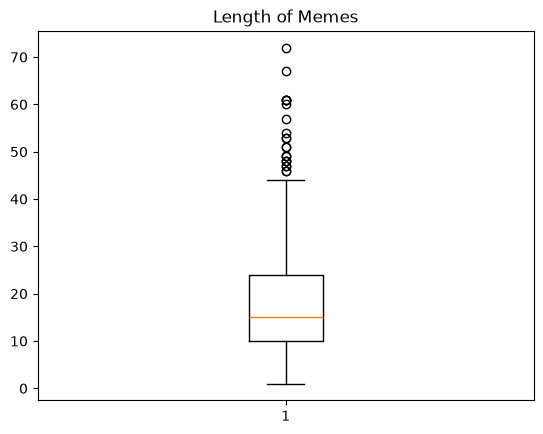

In [314]:
# Build vocabulary
all_train_tokens = [simple_tokenize(t) for t in train_set_task1["text"]]
word_counts = Counter()
for tokens in all_train_tokens:
    word_counts.update(tokens)

# Create two special tokens <PAD> and <UNK> to represent text-padding and unknown tokens respectively.
PAD_IDX, UNK_IDX = 0, 1
word_to_idx = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}
idx = 2
for word, count in word_counts.most_common():
    # Ignore extremely niche tokens.
    if count >= 5:
        word_to_idx[word] = idx
        idx += 1
    else:
        break

VOCAB_SIZE = len(word_to_idx)
MAX_LEN = 64
print(f'Vocabulary: {VOCAB_SIZE}, Max length: {MAX_LEN}')

# View the distribution of meme lengths according to our tokenizer.
plt.boxplot([len(train_token) for train_token in all_train_tokens])
plt.title("Length of Memes")

In [315]:
# Dataset class (same as Week 7)
class TextDataset(Dataset):
    def __init__(self, texts, labels, word_to_idx, tokenizer = simple_tokenize, max_len=MAX_LEN):
        self.labels = labels
        self.sequences, self.lengths = [], []
        for text in texts:
            tokens = tokenizer(text)
            indices = [word_to_idx.get(t, UNK_IDX) for t in tokens[:max_len]]
            self.lengths.append(len(indices))
            indices += [PAD_IDX] * (max_len - len(indices))
            self.sequences.append(indices)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.float32),
            self.lengths[idx],
        )

train_ds = TextDataset(train_set_task1["text"], train_set_task1["label_encoded"], word_to_idx)
val_ds = TextDataset(dev_set_task1["text"], dev_set_task1["label_encoded"], word_to_idx)
test_ds = TextDataset(test_set_task1["text"], test_set_task1["label_encoded"], word_to_idx)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, generator=generator)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, generator=generator)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, generator=generator)

## Models

### BASELINE MODEL (LSTM)

For my baseline model, I will be using a simple RNN, specifically LSTM. RNNs typically have many drawbacks relating to vanishing gradients due to the influence of earlier tokens being overwritten as time goes on. LSTM does aim to solve this problem by using several gates, however, they will still eventually fall to the same drawback. For this task specifically, however, the lengths of a meme should intuitively, not be too long. This is backed up by the boxplot of lengths of our memes below, which backs up that the median length of a meme is only ~15 tokens, which should theoretically be short enough to not fall to the vanishing gradient problem. It will most likely struggle on the longer memes, especially the high outliers of lengths >50. However, we can fix that in the later experiments.

In [316]:
# Baseline RNN model using LSTM.
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        
        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes),
        )
    
    def forward(self, x):
        x = self.embedding(x)
        output, hidden = self.rnn(x)
        
        hidden = hidden[0]
        
        return self.fc(hidden[-1])

### Training the Model:

The model seems to steadily learn in both the Training data as well as on the validation data. It seems to perform best at around epoch ~35. However, the model begins exhibiting signs of overfitting past epoch ~40 as training loss continues to decrease while validation loss spikes and trends upwards as epochs increases.

Parameters: 127,956


C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [RNN] Epoch 1/50 — Train: 1.2683 | Val: 1.6655
  [RNN] Epoch 10/50 — Train: 1.2646 | Val: 1.6709
  [RNN] Epoch 20/50 — Train: 1.2554 | Val: 1.6864
  [RNN] Epoch 30/50 — Train: 1.2544 | Val: 1.6656
  [RNN] Epoch 40/50 — Train: 1.2354 | Val: 1.6487
  [RNN] Epoch 50/50 — Train: 1.1836 | Val: 1.6526


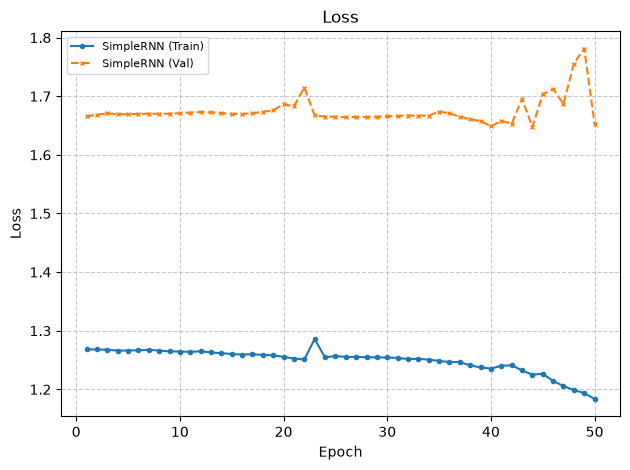

In [317]:
torch.manual_seed(67)
rnn_model = LSTMModel(
    VOCAB_SIZE, 64, 128, len(LABELS)
).to(device)

optimizer = optim.Adam(rnn_model.parameters(), lr=5e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=task1_label_weights)

print(f'Parameters: {sum(p.numel() for p in rnn_model.parameters()):,}')

SimpleRNN_results = {} 
SimpleRNN_results["SimpleRNN"] = run_experiment(
    rnn_model, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='RNN'
)

plot_experiments(SimpleRNN_results)

### Evaluating the Model:

A macro precision of 0.09 heavily implies that the model is currently making many False Positives. Looking at the per label precisions we see that most of the labels have precisions < 0.1. Labels such as Obfuscation, Red Herring and Bandwagon have precisions of 0 as the model is completely unable to correctly label a positive sample. Although macro and weighted recalls actually clear our naive goals, with values 0.65 and 0.71 respectively. The macro F1-scores of 0.14 and 0.37 for macro and weighted respectively shows that it comes at the cost of horrible precision. 

The model has a problem with predicting too many samples as positive for many labels, resulting in a spike of False Positives. 

C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resu

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0312      0.1429      0.0513           7      0.8150
Appeal to fear/preju         0.0789      0.3000      0.1250          10      0.7900
Black-and-white Fall         0.0400      1.0000      0.0769           7      0.1600
Causal Oversimplific         0.0500      0.6667      0.0930           3      0.8050
Doubt                        0.1707      0.2500      0.2029          28      0.7250
Exaggeration/Minimis         0.1176      0.2105      0.1509          19      0.7750
Flag-waving                  0.0306      1.0000      0.0594           6      0.0500
Glittering generalit         0.1515      0.4545      0.2273          11      0.8300
Loaded Language              0.7000      0.2800      0.4000         100      0.5800
Misrepresentation of         0.0000      0.0000      0.0000           1      0.7900
Name calling/Labelin         0.3824      0.2453      0.2989          53     

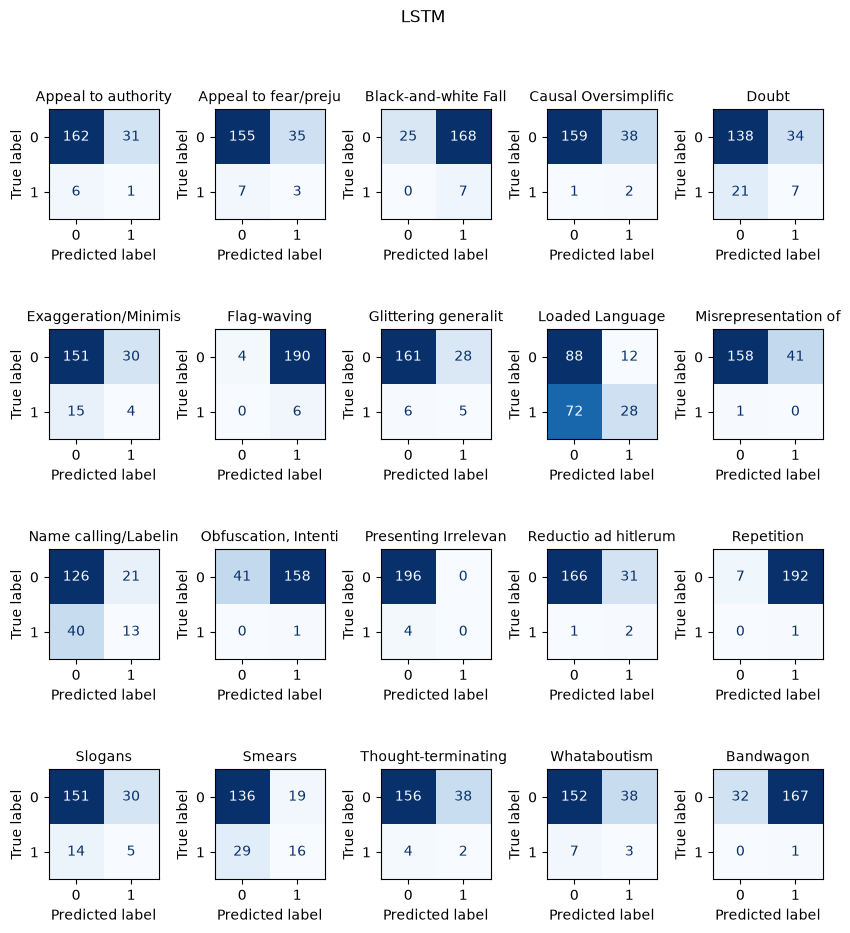

In [318]:
fig, report, accuracy = get_evaluation(rnn_model, test_loader, "LSTM")

view_report(report)
print(f"Total Accuracy: {accuracy}")

### Experiment 1: Pre-trained Dense Embeddings

For my first experiment, I would like to try to introduce pretrained Dense embeddings into our model rather than create these embeddings ourselves. By using a pretrained embedding space, each token's semantic meaning can be represented in the vector space as deemed fit by some large training data. This should make the model "understand" the meaning of each meme better so that it can make better decisions.

### GloVe:

I decide to choose GloVe as my pretrained embedder of choice. Specifically the 6B version which has an embedding dimension of 50 and is pretrained on a corpus of wikipedia articles, I decide to use this version rather than the others which have higher embedding dimensions simply because it is the smallest model which should fit our needs for this small experiment. If we decide later to use this model, with the GloVe embeddings, I might use the one with the bigger embedding dimension to improve performance. Because the corpus is very general it should be able to capture almost all tokens that we throw at it. 

In [319]:
# Taken from Week 7 Labs.

# Download GloVe 6B (50d — smallest version, ~66MB)
import urllib.request
import zipfile

GLOVE_DIM = 50
GLOVE_FILE = f'glove.6B.{GLOVE_DIM}d.txt'

if not os.path.exists(GLOVE_FILE):
    print('Downloading GloVe embeddings...')
    urllib.request.urlretrieve(
        'https://nlp.stanford.edu/data/glove.6B.zip', 'glove.6B.zip'
    )
    with zipfile.ZipFile('glove.6B.zip', 'r') as z:
        z.extract(GLOVE_FILE)
    print('Done.') 
else:
    print(f'{GLOVE_FILE} already exists.')

glove.6B.50d.txt already exists.


In [320]:
# Taken from Week 7 Labs.

# Load GloVe into a dictionary
def load_glove(filepath, dim):
    embeddings = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            if len(vector) == dim:
                embeddings[word] = vector
    return embeddings

glove = load_glove(GLOVE_FILE, GLOVE_DIM)
print(f'Loaded {len(glove):,} GloVe vectors ({GLOVE_DIM}d)')

# Check coverage
covered = sum(1 for w in word_to_idx if w in glove)
print(f'Vocabulary coverage: {covered}/{len(word_to_idx)} ({covered/len(word_to_idx)*100:.1f}%)')

Loaded 400,000 GloVe vectors (50d)
Vocabulary coverage: 402/407 (98.8%)


In [321]:
# Taken from Week 7 Labs.

def create_embedding_matrix(word_to_idx, glove, embed_dim):
    """Create an embedding matrix with GloVe vectors for known words."""
    matrix = np.zeros((len(word_to_idx), embed_dim))
    found, missing = 0, 0

    for word, idx in word_to_idx.items():
        if word in glove:
            matrix[idx] = glove[word]
            found += 1
        else:
            # Random initialisation for unknown words
            if word == "<PAD>":
                continue

            matrix[idx] = np.random.normal(scale=0.6, size=embed_dim)
            missing += 1

    print(f'Embedding matrix: {matrix.shape}')
    print(f'  Found in GloVe: {found}, Missing: {missing}')
    return torch.tensor(matrix, dtype=torch.float32)

embedding_matrix = create_embedding_matrix(word_to_idx, glove, GLOVE_DIM)

Embedding matrix: (407, 50)
  Found in GloVe: 402, Missing: 4


In [322]:
class DenseLSTM(nn.Module):
    def __init__(self, embedding_matrix, num_classes, hidden_dim, freeze_embeddings=True):
        super().__init__()
        
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=freeze_embeddings, padding_idx=PAD_IDX
        )

        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x):
        x = self.embedding(x)
        output, hidden = self.rnn(x)
        
        hidden = hidden[0]
        
        return self.fc(hidden[-1])

### Training the Model:

Not much of note has changed while training this new model. The model still has steady training progress until around > epoch 40 where it begins to overfit to the training data. Training loss values has not decreased by much compared to the previous model.

Parameters: 115,090


C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [DenseLSTM] Epoch 1/50 — Train: 1.2677 | Val: 1.6897
  [DenseLSTM] Epoch 10/50 — Train: 1.2678 | Val: 1.6940
  [DenseLSTM] Epoch 20/50 — Train: 1.2552 | Val: 1.6874
  [DenseLSTM] Epoch 30/50 — Train: 1.2435 | Val: 1.6237
  [DenseLSTM] Epoch 40/50 — Train: 1.1929 | Val: 1.6063
  [DenseLSTM] Epoch 50/50 — Train: 1.1463 | Val: 2.0068


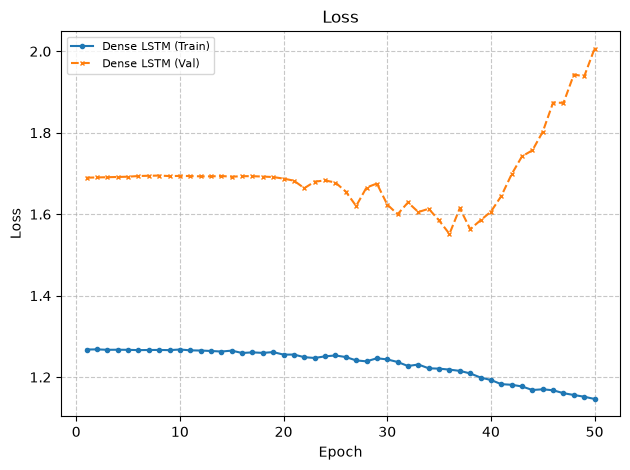

In [323]:
torch.manual_seed(67)
dense_lstm = DenseLSTM(
    embedding_matrix=embedding_matrix,
    num_classes=len(LABELS),
    hidden_dim=128,
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight = task1_label_weights)
optimizer = optim.Adam(dense_lstm.parameters(), lr=5e-4)

print(f'Parameters: {sum(p.numel() for p in dense_lstm.parameters()):,}')

DenseLSTM_Results = {}
DenseLSTM_Results['Dense LSTM'] = run_experiment(
    dense_lstm, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='DenseLSTM'
)

plot_experiments(DenseLSTM_Results)

### Evaluating the Model

These new changes have shown to improve the model's precision, with a higher macro precision of 0.11 vs the previous 0.09. This comes at a cost of slightly decreased macro recall, with a macro recall of 0.52 vs 0.65. More importantly, weighted macro recall drops significantly from 0.71 down to 0.52, implying that the model may have improved recall on several minority labels but decreased recall on the majority labels. This is most obviously demonstrated in Loaded Language, which previously had a recall of 0.75 but has now dropped to 0.54. Meanwhile labels such as Black and White fallacy, a minority label with only 7 positive samples, has increased from a recall of 0.42 to 1. However, for that specific label it is important to note that its accuracy has tremendously decreased from 0.5 to 0.05, as the model labels most of its samples as positive creating many false positives and not a lot of true negatives. This pattern can be seen across several other minority labels, such as Appeal to Authority and Causal Oversimplification (although in this scenario only accuracy went down, recall stayed the same). 

Overall, the model has improved, as recall is still near our acceptable range while precision, which was previously lacking, has somewhat improved while F1-score barely changes (macro F1 has increased from 0.14 to 0.15 but weighted F1 has decreased from 0.37 to 0.36). The model improves most on accuracy, with a total accuracy of 0.63 vs the previous 0.43. 

C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0364      0.2857      0.0645           7      0.7100
Appeal to fear/preju         0.1026      0.8000      0.1818          10      0.6400
Black-and-white Fall         0.0385      0.5714      0.0721           7      0.4850
Causal Oversimplific         0.0294      0.6667      0.0563           3      0.6650
Doubt                        0.1857      0.4643      0.2653          28      0.6400
Exaggeration/Minimis         0.1250      0.4211      0.1928          19      0.6650
Flag-waving                  0.0519      0.6667      0.0964           6      0.6250
Glittering generalit         0.1094      0.6364      0.1867          11      0.6950
Loaded Language              0.6944      0.5000      0.5814         100      0.6400
Misrepresentation of         0.0000      0.0000      0.0000           1      0.6450
Name calling/Labelin         0.3099      0.4151      0.3548          53     

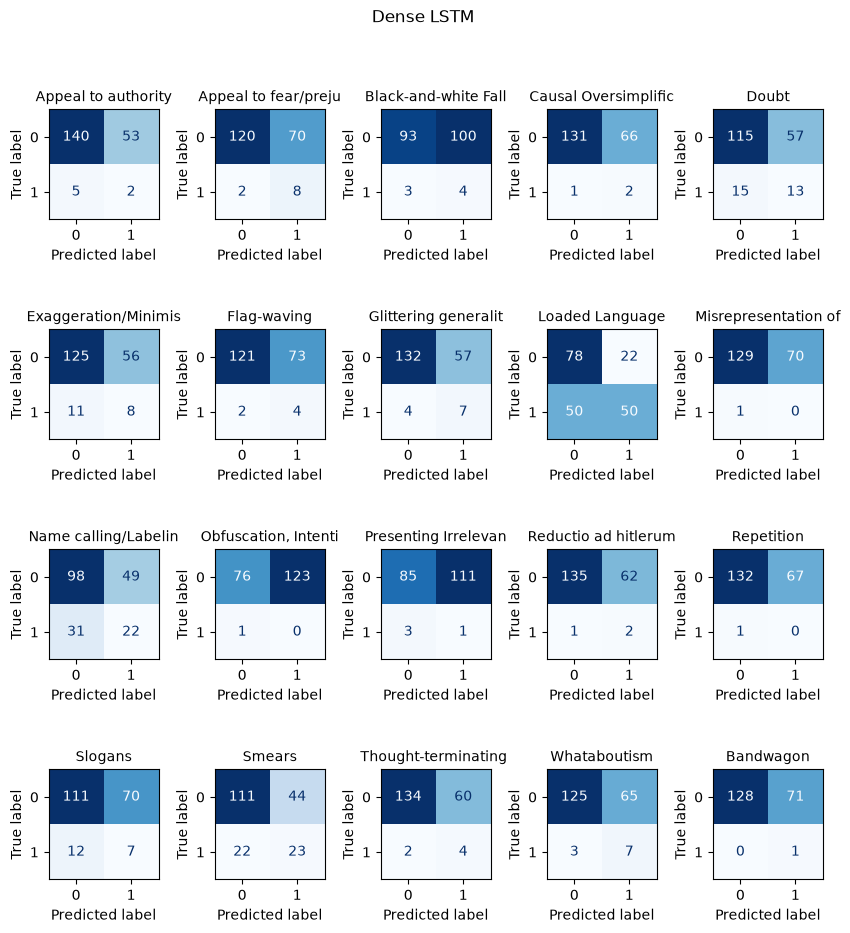

In [324]:
fig, report, accuracy = get_evaluation(dense_lstm, test_loader, "Dense LSTM")

view_report(report)
print(f"Total Accuracy: {accuracy}")

Our problems of having too many False Positives from the previous model, although decreased, still exists within the model. Meaning that there is something else which I will have to address. One observation I have made is that a majority of False Positives comes from minority labels, most obviously seen in Black and White Fallacy, Flag Waving, Obfuscation, etc. The label weights that I have created might be causing this problem. Viewing the generated label weights here, we see that a majority of minority labels have had their weights blown up, the most extreme ones being in the mid hundreds and Red Herring which has one positive sample has a weight of 687. These blown up weights means that creating a False Negative will be much more costly on these minority labels, and as such the model may be inclined to more likely label these classes as positive to try to avoid incurring these costs. 

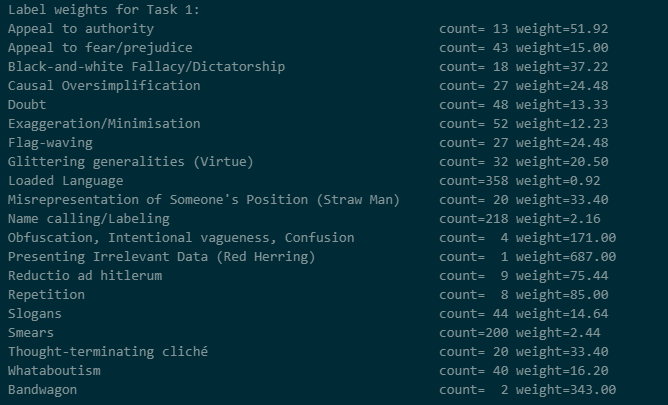

### Experiment 2: Fine Tuning Dense Embeddings (REJECTED)

Before addressing that issue, I would first also like to take time to see whether fine tuning the pretrained embeddings might also be worthwhile to do. The idea is that although we have a very general corpus for the trained embeddings, fine tuning the general embeddings of each token for our specific problem might make the model perform better.

### Training the Model:

The model's training is very similar to that of Experiment 1, not much of note is changed from those said in Experiment 1. 

Parameters: 115,090


C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [DenseLSTM (Finetuned)] Epoch 1/50 — Train: 1.2683 | Val: 1.6897
  [DenseLSTM (Finetuned)] Epoch 10/50 — Train: 1.2660 | Val: 1.6869
  [DenseLSTM (Finetuned)] Epoch 20/50 — Train: 1.2564 | Val: 1.6803
  [DenseLSTM (Finetuned)] Epoch 30/50 — Train: 1.2292 | Val: 1.5577
  [DenseLSTM (Finetuned)] Epoch 40/50 — Train: 1.2759 | Val: 1.6122
  [DenseLSTM (Finetuned)] Epoch 50/50 — Train: 1.1496 | Val: 1.7081


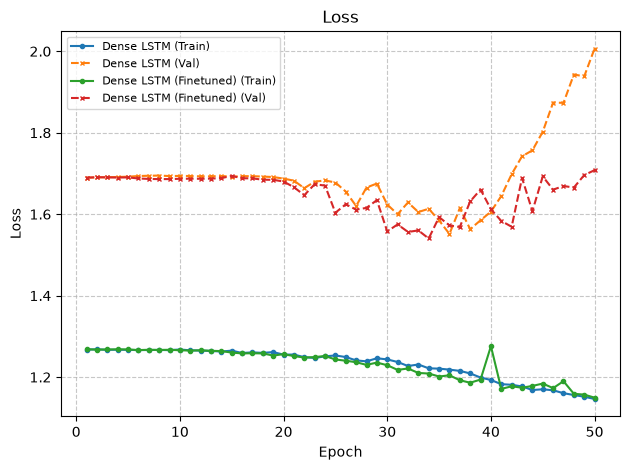

In [325]:
# Turn off freeze embeddings, to allow fine tuning on the embedding layer. 
torch.manual_seed(67)
dense_lstm_fine_tune = DenseLSTM(
    embedding_matrix=embedding_matrix,
    num_classes=len(LABELS),
    hidden_dim=128,
    freeze_embeddings=False
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=task1_label_weights)
optimizer = optim.Adam(dense_lstm_fine_tune.parameters(), lr=5e-4)

print(f'Parameters: {sum(p.numel() for p in dense_lstm_fine_tune.parameters()):,}')

DenseLSTM_Results['Dense LSTM (Finetuned)'] = run_experiment(
    dense_lstm_fine_tune, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='DenseLSTM (Finetuned)'
)

plot_experiments(DenseLSTM_Results)

### Evaluating the Model:

Overall trying to fine tune the model did not change much about its performance over the pretrained embeddings. All of precision, recall, f1 and accuracy all have very minor changes, none of which are substantially better or worse than without fine tuning. Nor did the model fix any of the underlying issues that we had with the previous model. I believe that because of this, the general embeddings trained on the general corpus was already fit for our needs and we should not need to waste extra compute to train new parameters for the embeddings. Hence why I reject this proposition and will not fine tune the current Dense embeddings we have.

C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0597      0.5714      0.1081           7      0.6700
Appeal to fear/preju         0.0899      0.8000      0.1616          10      0.5850
Black-and-white Fall         0.0359      1.0000      0.0693           7      0.0600
Causal Oversimplific         0.0230      0.6667      0.0444           3      0.5700
Doubt                        0.1591      0.5000      0.2414          28      0.5600
Exaggeration/Minimis         0.1299      0.5263      0.2083          19      0.6200
Flag-waving                  0.0460      0.6667      0.0860           6      0.5750
Glittering generalit         0.0864      0.6364      0.1522          11      0.6100
Loaded Language              0.6477      0.5700      0.6064         100      0.6300
Misrepresentation of         0.0000      0.0000      0.0000           1      0.5750
Name calling/Labelin         0.2955      0.4906      0.3688          53     

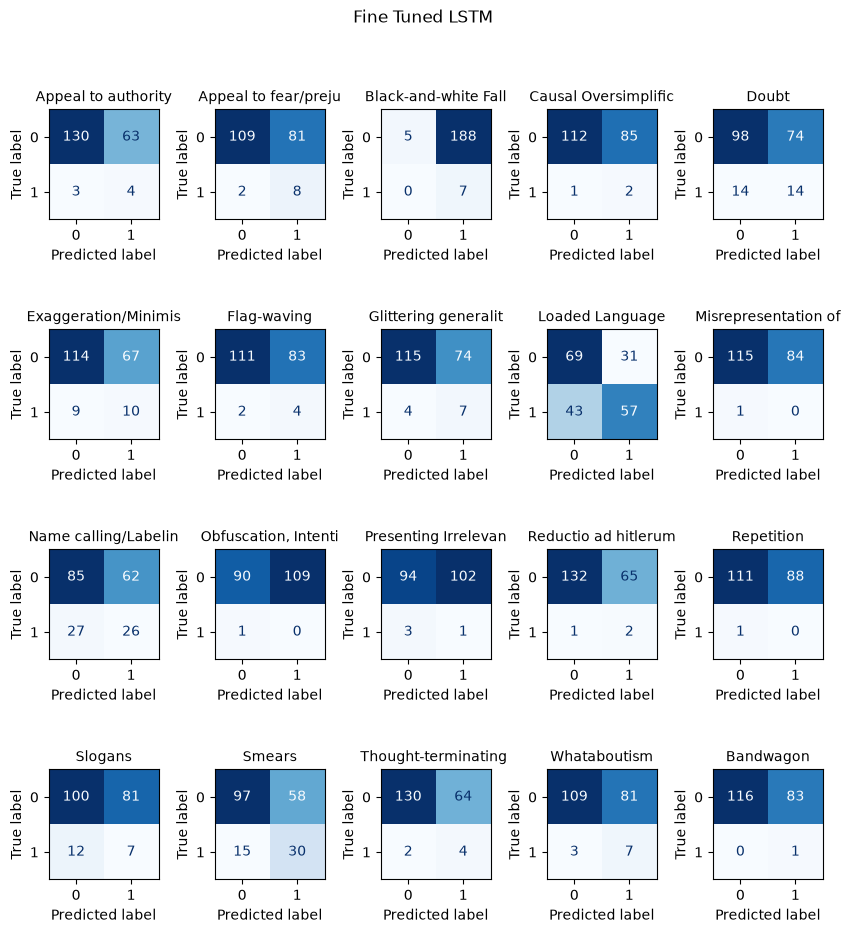

In [326]:
fig, report, accuracy = get_evaluation(dense_lstm_fine_tune, test_loader, "Fine Tuned LSTM")

view_report(report)
print(f"Total Accuracy: {accuracy}")

### Experiment 3: Modify Class Weight

To address the problems brought up in Experiment 1, I decide to modify my label weights by testing different weight calculations. These include: square root transformation, log transformation and simple clamping. 

In [327]:
# Do a square root transformation. Should reduce the effects of exploded weights while maintaining the balance.
task1_sqrt_weights = torch.sqrt(task1_label_weights)

# Do log transformation. Much more aggressive reduction for the exploded weights.
task1_log_weights = torch.tensor(
    [
        math.log1p(total / task1_label_counts[label])
        if task1_label_counts[label] > 0 else 1
        for label in LABELS
    ]
)

# Clamping. Does not change the reduction technique but just clamps it so weights don't explode. 
MAX_WEIGHT = 80
MIN_WEIGHT = 0
task1_clamped_weights = torch.clamp(task1_label_weights, min = MIN_WEIGHT, max = MAX_WEIGHT)

print('Sqrt Label weights for Task 1:')
for i, label in enumerate(LABELS):
    print(
        f"{label:<55} "
        f"count={task1_label_counts[label]:>3} "
        f"weight={task1_sqrt_weights[i].item():.2f}"
    )
    
print('Log Label weights for Task 1:')
for i, label in enumerate(LABELS):
    print(
        f"{label:<55} "
        f"count={task1_label_counts[label]:>3} "
        f"weight={task1_log_weights[i].item():.2f}"
    )

print('Clamped Label weights for Task 1:')
for i, label in enumerate(LABELS):
    print(
        f"{label:<55} "
        f"count={task1_label_counts[label]:>3} "
        f"weight={task1_clamped_weights[i].item():.2f}"
    )

Sqrt Label weights for Task 1:
Appeal to authority                                     count= 13 weight=7.21
Appeal to fear/prejudice                                count= 43 weight=3.87
Black-and-white Fallacy/Dictatorship                    count= 18 weight=6.10
Causal Oversimplification                               count= 27 weight=4.95
Doubt                                                   count= 48 weight=3.65
Exaggeration/Minimisation                               count= 52 weight=3.50
Flag-waving                                             count= 27 weight=4.95
Glittering generalities (Virtue)                        count= 32 weight=4.53
Loaded Language                                         count=358 weight=0.96
Misrepresentation of Someone's Position (Straw Man)     count= 20 weight=5.78
Name calling/Labeling                                   count=218 weight=1.47
Obfuscation, Intentional vagueness, Confusion           count=  4 weight=13.08
Presenting Irrelevant Data (Red 

In [328]:
torch.manual_seed(67)
dense_lstm_sqrt_weight = DenseLSTM(
    embedding_matrix=embedding_matrix,
    num_classes=len(LABELS),
    hidden_dim=128,
    freeze_embeddings=True
).to(device)

optimizer = optim.Adam(dense_lstm_sqrt_weight.parameters(), lr=5e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=task1_sqrt_weights)

print(f'Parameters: {sum(p.numel() for p in dense_lstm_sqrt_weight.parameters()):,}')

ModifiedWeights_Results = {}
ModifiedWeights_Results['RNN Sqrt Weights'] = run_experiment(
    dense_lstm_sqrt_weight, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='RNN Sqrt Weights'
)

Parameters: 115,090


C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [RNN Sqrt Weights] Epoch 1/50 — Train: 0.7703 | Val: 0.7989
  [RNN Sqrt Weights] Epoch 10/50 — Train: 0.5087 | Val: 0.6223
  [RNN Sqrt Weights] Epoch 20/50 — Train: 0.5084 | Val: 0.6280
  [RNN Sqrt Weights] Epoch 30/50 — Train: 0.5086 | Val: 0.6274
  [RNN Sqrt Weights] Epoch 40/50 — Train: 0.5068 | Val: 0.6301
  [RNN Sqrt Weights] Epoch 50/50 — Train: 0.5061 | Val: 0.6273


In [329]:
torch.manual_seed(67)
dense_lstm_log_weight = DenseLSTM(
    embedding_matrix=embedding_matrix,
    num_classes=len(LABELS),
    hidden_dim=128,
    freeze_embeddings=True
).to(device)

optimizer = optim.Adam(dense_lstm_log_weight.parameters(), lr=5e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=task1_log_weights)

print(f'Parameters: {sum(p.numel() for p in dense_lstm_log_weight.parameters()):,}')

ModifiedWeights_Results['RNN log Weights'] = run_experiment(
    dense_lstm_log_weight, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='RNN Sqrt Weights'
)

Parameters: 115,090


C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [RNN Sqrt Weights] Epoch 1/50 — Train: 0.7357 | Val: 0.7445
  [RNN Sqrt Weights] Epoch 10/50 — Train: 0.4066 | Val: 0.4636
  [RNN Sqrt Weights] Epoch 20/50 — Train: 0.4027 | Val: 0.4668
  [RNN Sqrt Weights] Epoch 30/50 — Train: 0.3987 | Val: 0.4665
  [RNN Sqrt Weights] Epoch 40/50 — Train: 0.4013 | Val: 0.4661
  [RNN Sqrt Weights] Epoch 50/50 — Train: 0.4004 | Val: 0.4648


Parameters: 115,090


C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [RNN Clamped Weights] Epoch 1/50 — Train: 1.1879 | Val: 1.3885
  [RNN Clamped Weights] Epoch 10/50 — Train: 1.1531 | Val: 1.4534
  [RNN Clamped Weights] Epoch 20/50 — Train: 1.1493 | Val: 1.4246
  [RNN Clamped Weights] Epoch 30/50 — Train: 1.1281 | Val: 1.3908
  [RNN Clamped Weights] Epoch 40/50 — Train: 1.0669 | Val: 1.4102
  [RNN Clamped Weights] Epoch 50/50 — Train: 1.0738 | Val: 1.4606


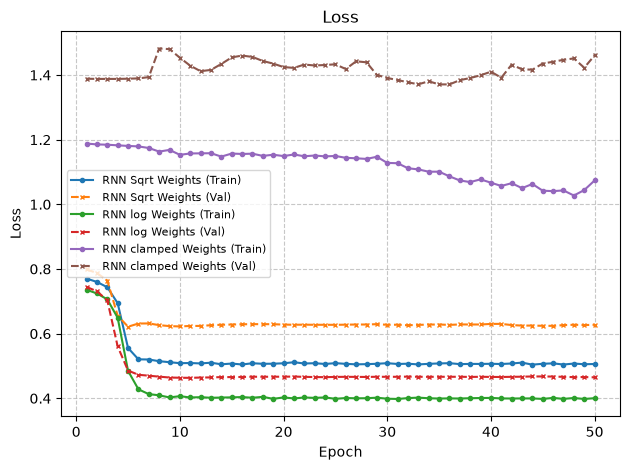

In [330]:
torch.manual_seed(67)
dense_lstm_clamped_weight = DenseLSTM(
    embedding_matrix=embedding_matrix,
    num_classes=len(LABELS),
    hidden_dim=128,
    freeze_embeddings=True
).to(device)

optimizer = optim.Adam(dense_lstm_clamped_weight.parameters(), lr=5e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=task1_clamped_weights)

print(f'Parameters: {sum(p.numel() for p in dense_lstm_clamped_weight.parameters()):,}')

ModifiedWeights_Results['RNN clamped Weights'] = run_experiment(
    dense_lstm_clamped_weight, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='RNN Clamped Weights'
)

plot_experiments(ModifiedWeights_Results)

C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resu

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0000      0.0000      0.0000           7      0.9650
Appeal to fear/preju         0.0000      0.0000      0.0000          10      0.9500
Black-and-white Fall         0.0000      0.0000      0.0000           7      0.9650
Causal Oversimplific         0.0000      0.0000      0.0000           3      0.9850
Doubt                        0.0000      0.0000      0.0000          28      0.8600
Exaggeration/Minimis         0.0000      0.0000      0.0000          19      0.9050
Flag-waving                  0.0000      0.0000      0.0000           6      0.9700
Glittering generalit         0.0000      0.0000      0.0000          11      0.9450
Loaded Language              0.0000      0.0000      0.0000         100      0.5000
Misrepresentation of         0.0000      0.0000      0.0000           1      0.9950
Name calling/Labelin         0.0000      0.0000      0.0000          53     

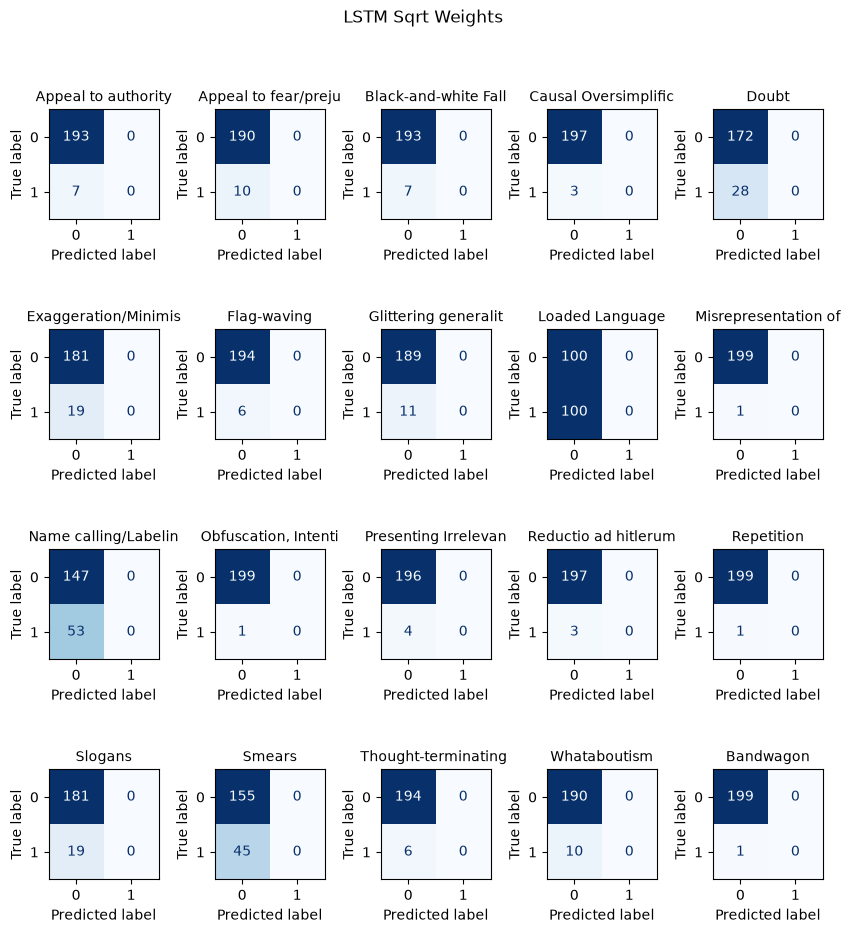

In [331]:
fig, report, accuracy = get_evaluation(dense_lstm_sqrt_weight, test_loader, "LSTM Sqrt Weights")

view_report(report)
print(f"Total Accuracy: {accuracy}")

C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resu

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0000      0.0000      0.0000           7      0.9650
Appeal to fear/preju         0.0000      0.0000      0.0000          10      0.9500
Black-and-white Fall         0.0000      0.0000      0.0000           7      0.9650
Causal Oversimplific         0.0000      0.0000      0.0000           3      0.9850
Doubt                        0.0000      0.0000      0.0000          28      0.8600
Exaggeration/Minimis         0.0000      0.0000      0.0000          19      0.9050
Flag-waving                  0.0000      0.0000      0.0000           6      0.9700
Glittering generalit         0.0000      0.0000      0.0000          11      0.9450
Loaded Language              0.5000      1.0000      0.6667         100      0.5000
Misrepresentation of         0.0000      0.0000      0.0000           1      0.9950
Name calling/Labelin         0.0000      0.0000      0.0000          53     

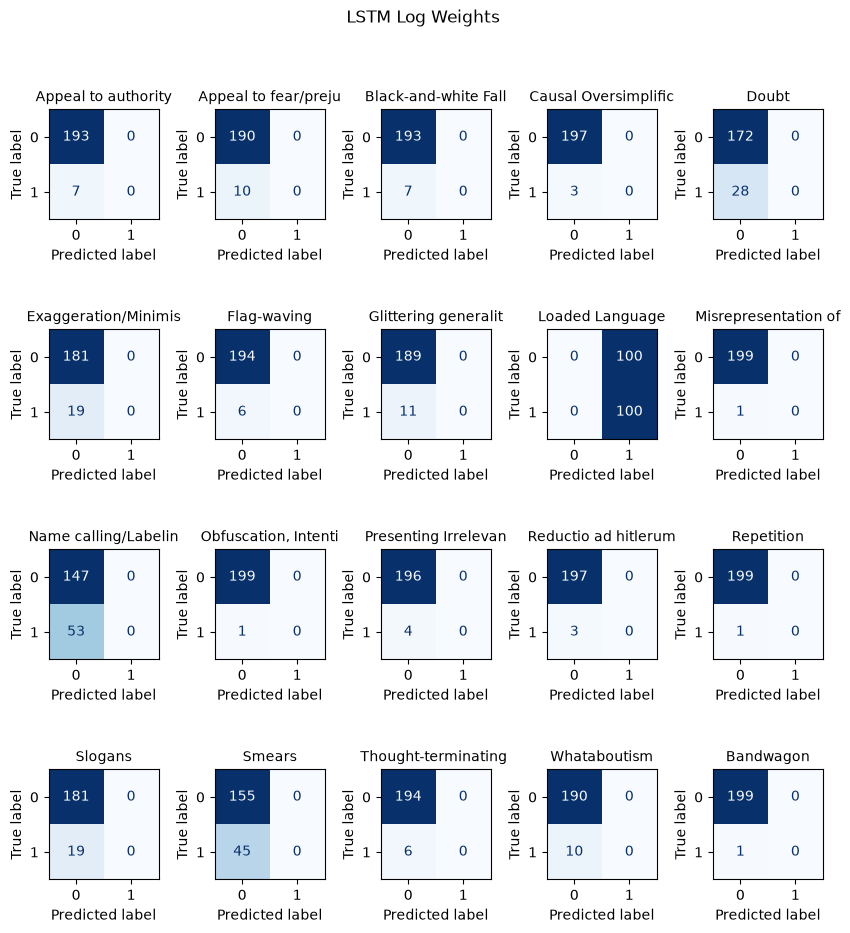

In [332]:
fig, report, accuracy = get_evaluation(dense_lstm_log_weight, test_loader, "LSTM Log Weights")

view_report(report)
print(f"Total Accuracy: {accuracy}")

C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resu

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0633      0.7143      0.1163           7      0.6200
Appeal to fear/preju         0.0750      0.6000      0.1333          10      0.6100
Black-and-white Fall         0.0423      0.4286      0.0769           7      0.6400
Causal Oversimplific         0.0256      0.6667      0.0494           3      0.6150
Doubt                        0.1687      0.5000      0.2523          28      0.5850
Exaggeration/Minimis         0.1084      0.4737      0.1765          19      0.5800
Flag-waving                  0.0187      0.3333      0.0354           6      0.4550
Glittering generalit         0.1071      0.8182      0.1895          11      0.6150
Loaded Language              0.6364      0.5600      0.5957         100      0.6200
Misrepresentation of         0.0000      0.0000      0.0000           1      0.5900
Name calling/Labelin         0.2907      0.4717      0.3597          53     

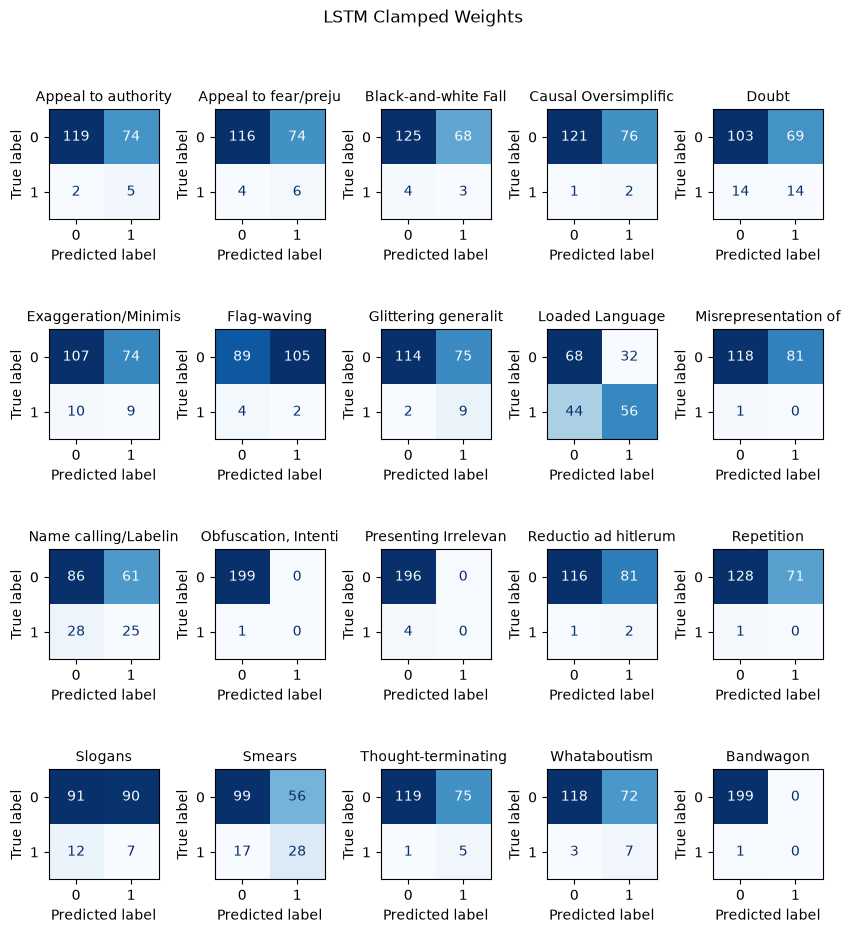

In [333]:
fig, report, accuracy = get_evaluation(dense_lstm_clamped_weight, test_loader, "LSTM Clamped Weights")

view_report(report)
print(f"Total Accuracy: {accuracy}")

### Evaluating the Model(s):

I will disregard the Sqrt and Log weights, as even just from a quick look at their confusion matrices, it is clear that there is an extreme case of overfitting and no generalization to be had. For every label within those models, they are labelled always positive or always negative. They are completely unfit. I believe that this is due to the fact that the log and square root transformations, although reducing the blown up class weights have at the same time also lost the magnitude of the class weights that we needed for good prediction behaviour. Clamped weights on the other hand seems to be somewhat fit for further evaluation.

The only notable change in our metrics is macro recall which has significantly dropped from 0.45 to 0.38. All other values, including weighted recall stay at roughly the same level. Another thing of note is that model accuracy has increased from 0.64 to 0.71. Looking at the confusion matrices, we see that some of the extreme minority labels such as Obfuscation and Red Herring have completely shut down to only predicting negatives. All other classes, especially majority classes, remain almost completely unchanged. What's interesting is that not all minority classes have necessarily improved by having less False Positives as I had hoped. Appeal to Authority is a minority class which in Dense LSTM had 53 false positives, which increased to 62 here. I noticed that among the minority classes, the only ones which have improved by having less false positives are ones whose weights were clamped. Appeal to Authority had a base weighting of ~51, which did not exceed our cap of 80 and therefore was not changed.

What I noticed as I reduced the cap lower and lower was that the other minority classes did not improve even with the lowered cap, and instead actually became worse. What I believe this implies is that by decreasing the maximum weight of our label weights, we are reducing the effect of magnitude between label weights. If we reduced the cap to 60, Appeal to Authority which has 13 positive samples would have nearly the same weight as Red Herring which has 1 positive sample.

Because square root transformation and log transformation is too aggressive of options for us to pursue, clamping might be the current best option that we have for dealing with the exploding weights problem, however, it alone is not enough to fix the False Positives problem.

### The Severe Label Imbalance Problem:

One of the issues that we have had for the past few models is a precision, recall and f1-score of 0 on some of the severe minority labels, namely Red Herring, Obfuscation and Bandwagon. These are the labels with the fewest number of positive samples in the entire dataset, especially because there is only ~1-4 positive samples in the testing dataset, we will continue to have extremely unstable values of precision, recall and f1 score for these labels, making them unreliable metrics for those labels. As such these labels will be poor indicators for the model's overall performance. In the clamped weighting experiment, these labels underwent prediction collapse with the model predicting every sample as negative for those labels, however, I take this as a good news for the model as it removes all the false positives from those labels which the model previously made. As I would rather the model to very rarely or almost never flag a technique as being used than for it to flag a meme for a technique it very explicitly does not use.

Going back to my justification for recall over precision, while it is true that it is possible that the samples not marked for having a technique, may simply have it but not be labelled by the analysts, looking at a small list of the texts the model predicts as "Obfuscation" compared to the list of positives in the training data, there does not seem to be a common overlap that shows that both uses the same technique. To which I don't think the argument can stand anymore. 

In [334]:
obfuscation_data = train_set_task1[
    train_set_task1["labels"].apply(lambda x: "Obfuscation, Intentional vagueness, Confusion" in x)
]

for i in range(4):
    print(obfuscation_data["text"].iloc[i])

THE PEOPLE WHO ONCE CALLED OUR SOLDIERS BABY KILLERS

NOW MARCH FOR THE RIGHT TO KILL BABIES

21 people running for President and only 1 stands against killing babies

SORRY, BUT I DON'T LISTEN TO ANTI-GUN LECTURES FROM PEOPLE WHO THINK IT'S OK TO KILL A BABY.
"Spreading the chemtrails is actually quite easy."

"Getting them right to the edge of the Earth without flying off into space is the difficult part."




### Experiment 4: Adjusting Confidence Threshold

Another experiment I am thinking to solve the false-positive issues is by increasing the confidence threshold. Currently, by default we use probabilities above 0.5 to be a true label. However, the logic is that if we increase the minimum threshold, only samples where the model is extremely confident about its label will be flagged positive, lowering the number of positive labels, lowering the number of false positives. Additionally, we can configure the threshold for each label so that certain labels will need to be more confident and others can be less. This should allow us to finetune each label's flagging distribution, we can exhibit that behaviour on one label here.

In [335]:
# Check the evaluation metrics for each label when using different thresholds within the range (0.4 to 0.6)
thresholds = torch.arange(0.4, 0.61, 0.01)

precisions = []
recalls = []
f1_scores = []
accuracies = []

for threshold in thresholds:
    fig, report, acc = get_evaluation(
        dense_lstm_clamped_weight,
        val_loader,
        f"LSTM Threshold {threshold:.2f}",
        prob_thresholds=[threshold for i in range(len(LABELS))]
    )

    precisions.append(report["Loaded Language"]["precision"])
    recalls.append(report["Loaded Language"]["recall"])
    f1_scores.append(report["Loaded Language"]["f1-score"])
    accuracies.append(acc)
    
    plt.close(fig)

C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resu

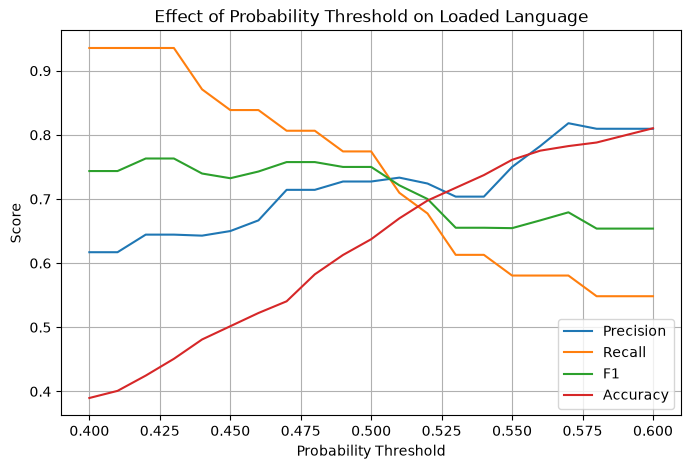

In [336]:
# View the effect of prob threshold on one Label, to prove that this will improve our model.
plt.figure(figsize=(8, 5))

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1_scores, label="F1")
plt.plot(thresholds, accuracies, label="Accuracy")

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Effect of Probability Threshold on Loaded Language")
plt.legend()
plt.grid()
plt.show()

In [337]:
def threshold_testing(label, model, loader = val_loader, tokenizer_mode=False):
    # Do the threshold testing before but per label and increase range to (0.3, 0.7)
    thresholds = torch.arange(0.3, 0.71, 0.01)

    precisions = []
    recalls = []
    f1_scores = []
    accuracies = []

    for threshold in thresholds:
        fig, report, acc = get_evaluation(
            model,
            loader,
            "",
            tokenizer_mode=tokenizer_mode,
            prob_thresholds=[threshold for i in range(len(LABELS))]
        )
        
        clear_output(True)

        precisions.append(report[label]["precision"])
        recalls.append(report[label]["recall"])
        f1_scores.append(report[label]["f1-score"])
        accuracies.append(acc)
        
        plt.close(fig)
    
    return thresholds, precisions, recalls, f1_scores, accuracies

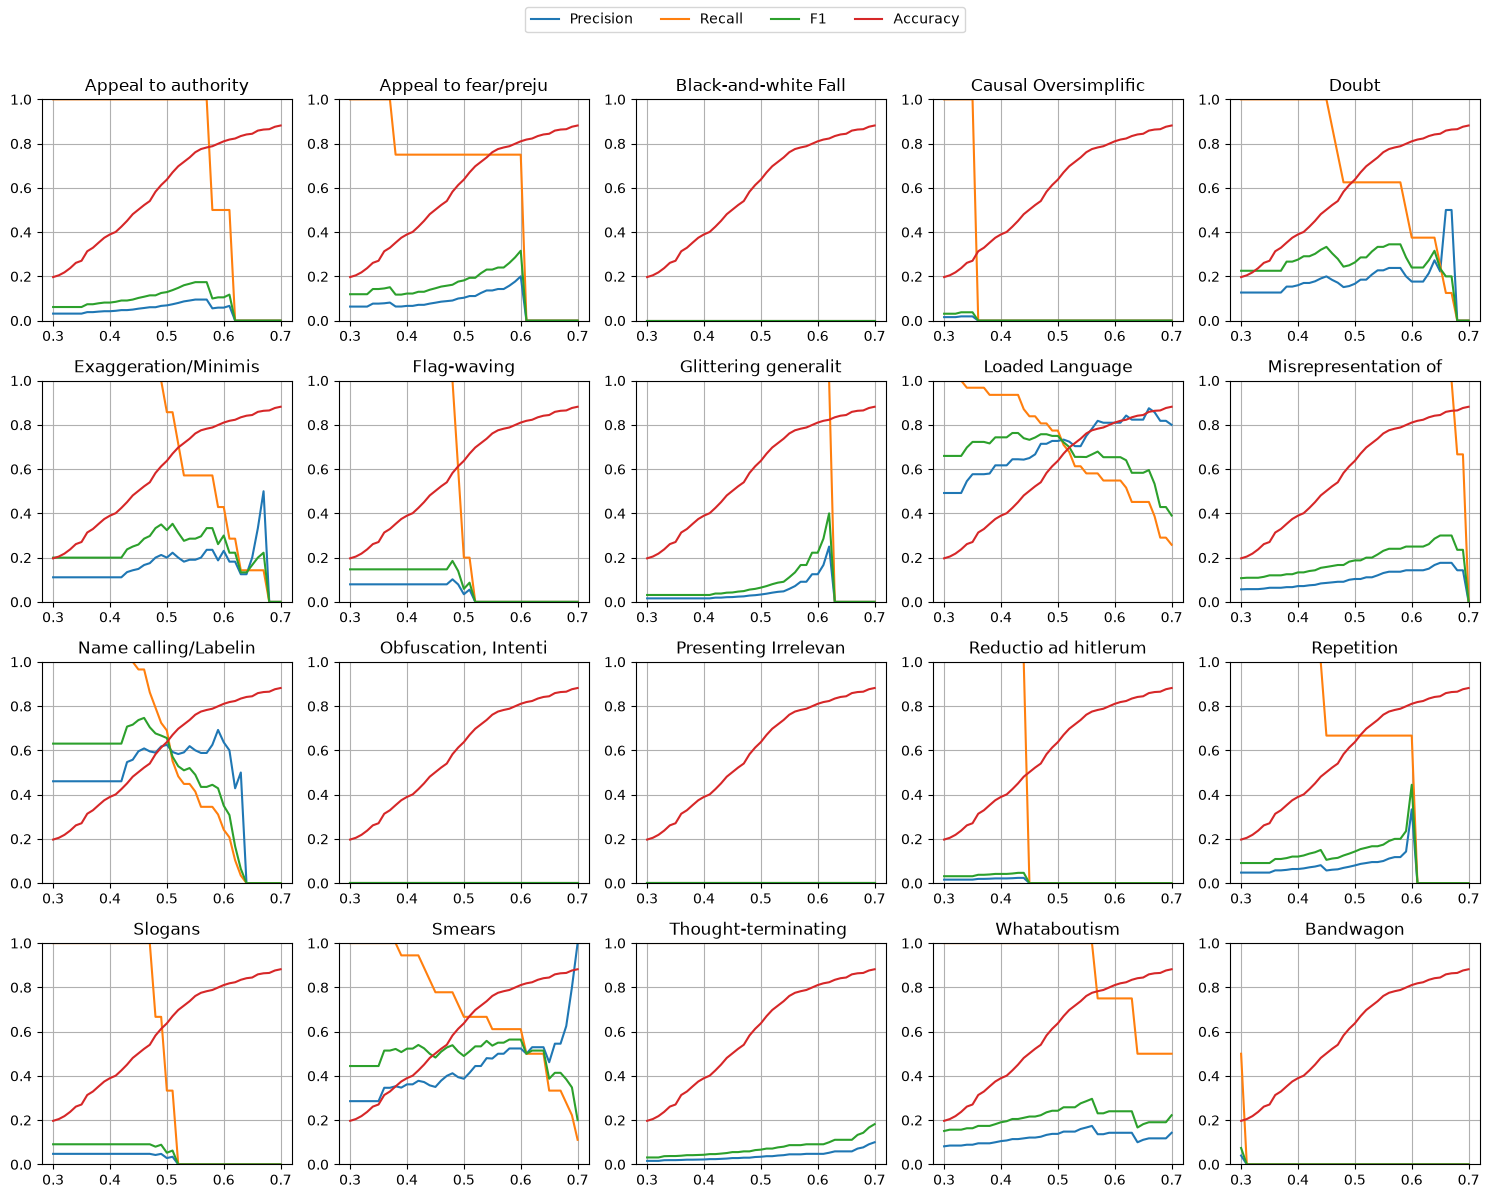

In [338]:
from IPython.display import clear_output

fig, ax = plt.subplots(4, 5, figsize=(15, 12))

# Do threshold testing on every model and plot their graphs. 
for i, label in enumerate(LABELS):
    thresholds, precisions, recalls, f1_scores, accuracies = threshold_testing(label, dense_lstm_clamped_weight)
    clear_output(True)

    current_ax = ax[i // 5, i % 5]

    current_ax.plot(thresholds, precisions, label="Precision")
    current_ax.plot(thresholds, recalls, label="Recall")
    current_ax.plot(thresholds, f1_scores, label="F1")
    current_ax.plot(thresholds, accuracies, label="Accuracy")

    current_ax.set_title(label[:20])
    current_ax.set_ylim(0, 1)
    current_ax.grid()
    
# Legends
handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [339]:
# Set the thresholds to what I deem to be appropriate threshold levels for each label.
# For labels where performance does not change too much from 0.5, we skip.
# For labels where the performance graph is too abnormal to interpret, we skip.
THRESHOLDS = [0.5 for i in range(len(LABELS))]

THRESHOLDS[LABELS.index("Appeal to fear/prejudice")] = 0.65
THRESHOLDS[LABELS.index("Exaggeration/Minimisation")] = 0.45
THRESHOLDS[LABELS.index("Glittering generalities (Virtue)")] = 0.6
THRESHOLDS[LABELS.index("Loaded Language")] = 0.45
THRESHOLDS[LABELS.index("Misrepresentation of Someone's Position (Straw Man)")] = 0.55
THRESHOLDS[LABELS.index("Name calling/Labeling")] = 0.45
THRESHOLDS[LABELS.index("Repetition")] = 0.6

### Evaluation:

By simply adjusting the probability thresholds of several labels we are able to marginally increase some of our evaluation metrics. With the current set up of thresholds that I have made, I was able to substantially increase weighted recall value from 0.45 to 0.57 while maintaining somewhat stable values for the rest of the metrics. 

However, for the remaining experiments, I will not use these thresholds. Because the output of logits and probabilities for each model will vary wildly with different implementations, we cannot have one concrete set of thresholds which will work with every model. Threshold tuning will be a good tool to use for the final model, however, for experimentation I will leave them out. 

C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", resu

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0633      0.7143      0.1163           7      0.6200
Appeal to fear/preju         0.0000      0.0000      0.0000          10      0.9500
Black-and-white Fall         0.0423      0.4286      0.0769           7      0.6400
Causal Oversimplific         0.0256      0.6667      0.0494           3      0.6150
Doubt                        0.1687      0.5000      0.2523          28      0.5850
Exaggeration/Minimis         0.1111      0.7368      0.1931          19      0.4150
Flag-waving                  0.0187      0.3333      0.0354           6      0.4550
Glittering generalit         0.1579      0.2727      0.2000          11      0.8800
Loaded Language              0.6000      0.6600      0.6286         100      0.6100
Misrepresentation of         0.0000      0.0000      0.0000           1      0.6700
Name calling/Labelin         0.2628      0.6792      0.3789          53     

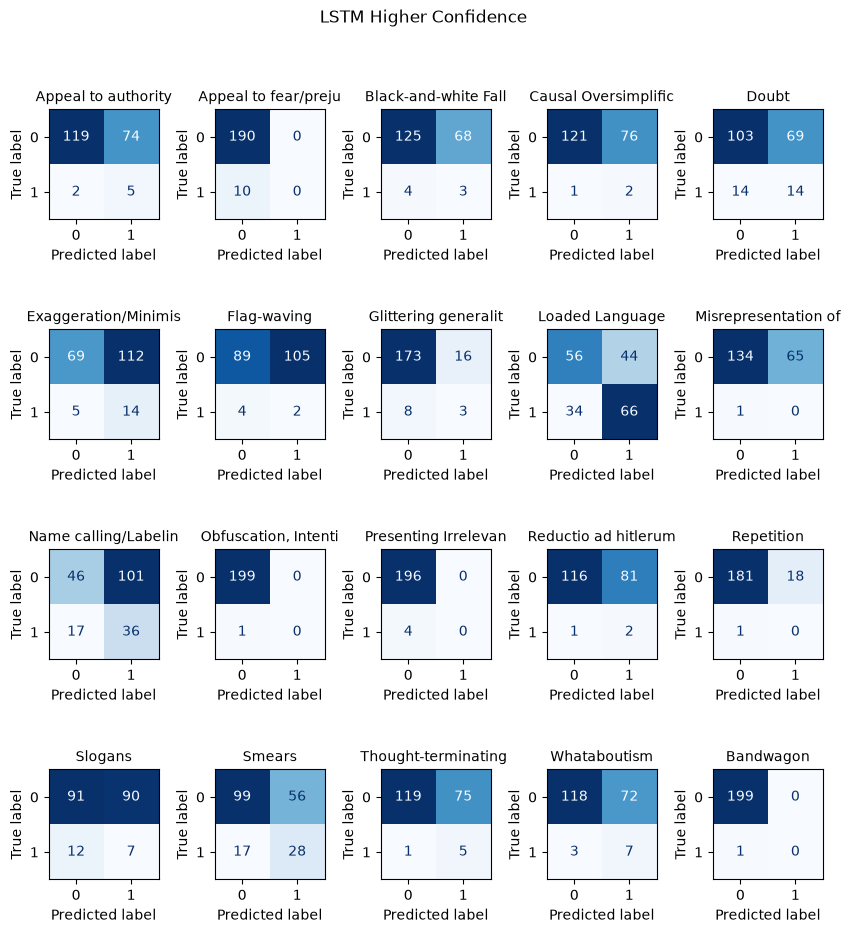

In [340]:
fig, report, accuracy = get_evaluation(dense_lstm_clamped_weight, test_loader, "LSTM Higher Confidence", prob_thresholds=THRESHOLDS)

view_report(report)
print(f"Total Accuracy: {accuracy}")

### Experiment 5: Transformers

Finally, I try to improve the model by switching to using a Transformer Encoder architecture. To do this, I modify the existing LSTM architecture to introduce a positional encoding layer using sinusoidal encoding, as well as a TransformerEncoder layer. The idea is that we are encountering a vanishing gradient problem as a result of LSTM's inherent drawbacks. Transformers aim to fix that problem by using multi-headed attention layers such that all tokens are able to view each other all at once and update themselves all at once, resulting in no information loss. 

In [341]:
class DenseTransformer(nn.Module):
    def __init__(self, embedding_matrix, num_heads, num_layers, num_classes, max_len=MAX_LEN, freeze_embeddings=True):
        super().__init__()
        
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=freeze_embeddings, padding_idx=PAD_IDX
        )

        self.pos_encoding = PositionalEncoding(embed_dim, max_len)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(embed_dim, num_classes)
        )
    
    def forward(self, x, lengths=None):
        # Create padding mask: True where padded
        pad_mask = (x == PAD_IDX)  # (batch, seq_len)
                
        x = self.embedding(x)
        x = self.pos_encoding(x)
        x = self.transformer(x, src_key_padding_mask=pad_mask)
        
        # Mean pooling (mask out padding)
        mask = (~pad_mask).unsqueeze(-1).float()  # (batch, seq_len, 1)
        x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        
        return self.fc(x)

### Training the Model:

Training the model was much more steady and loss decreases faster compared to the LSTM models. However, it began overfitting much earlier at around epoch ~23. 

Parameters: 82,670


C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),


  [DenseTransformer] Epoch 1/50 — Train: 1.2432 | Val: 1.4178
  [DenseTransformer] Epoch 10/50 — Train: 1.0823 | Val: 1.3396
  [DenseTransformer] Epoch 20/50 — Train: 1.0220 | Val: 1.3163
  [DenseTransformer] Epoch 30/50 — Train: 0.9361 | Val: 1.3666
  [DenseTransformer] Epoch 40/50 — Train: 0.8414 | Val: 1.5054
  [DenseTransformer] Epoch 50/50 — Train: 0.7559 | Val: 1.6166


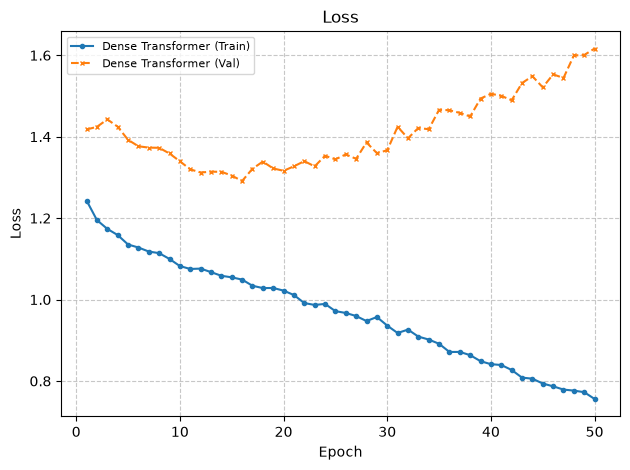

In [342]:
torch.manual_seed(67)
dense_tf = DenseTransformer(
    embedding_matrix=embedding_matrix,
    num_heads=2,
    num_layers=2,
    num_classes=len(LABELS),
    freeze_embeddings=True
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=task1_clamped_weights)
optimizer = optim.Adam(dense_tf.parameters(), lr=5e-4)

print(f'Parameters: {sum(p.numel() for p in dense_tf.parameters()):,}')

DenseTransformer_Results = {}
DenseTransformer_Results['Dense Transformer'] = run_experiment(
    dense_tf, optimizer, criterion, train_loader, val_loader,
    epochs=50, name='DenseTransformer'
)

plot_experiments(DenseTransformer_Results)

### Evaluating the Model:

This model performs very similarly to the LSTM model. Overall accuracy is very similar (0.68 vs 0.71), macro precisions are very similar (0.11 and 0.32 for macro and weighted vs LSTM's 0.11 and 0.35). This model's biggest differences seems to be a much higher Recall value with macro 0.44 and weighted 0.57 compared to LSTM's 0.38 and 0.45 and as such higher F1-score with macro 0.16 and weighted 0.37 compared to LSTM's 0.14 and 0.34. The per label differences between LSTM and Transformer seems to be quite random, some labels such as Flag Waving have very clear identifiable performance increases in precision, recall, f1 score and accuracy, while others seem to follow a similar distribution as in LSTM. The high number of False Positives still plague this model.

It appears that there is not a significant advantage of using a transformer over an RNN in this task, most likely due to the short length of the memes not significantly incurring RNN's vanishing gradient problem.  

C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2240541016.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.labels[idx], dtype=torch.float32),
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0619      1.0000      0.1167           7      0.4700
Appeal to fear/preju         0.1250      0.8000      0.2162          10      0.7100
Black-and-white Fall         0.0702      0.5714      0.1250           7      0.7200
Causal Oversimplific         0.0312      0.6667      0.0597           3      0.6850
Doubt                        0.2093      0.6429      0.3158          28      0.6100
Exaggeration/Minimis         0.1346      0.3684      0.1972          19      0.7150
Flag-waving                  0.0526      0.3333      0.0909           6      0.8000
Glittering generalit         0.0986      0.6364      0.1707          11      0.6600
Loaded Language              0.6237      0.5800      0.6010         100      0.6150
Misrepresentation of         0.0000      0.0000      0.0000           1      0.6250
Name calling/Labelin         0.2804      0.5660      0.3750          53     

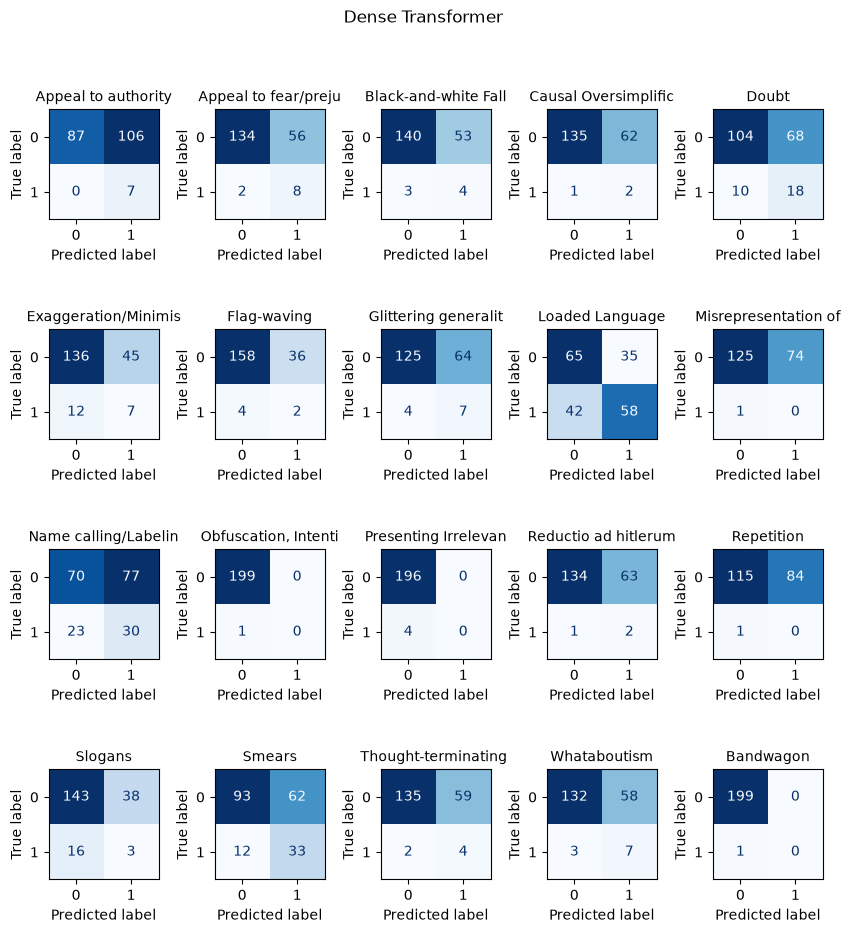

In [343]:
fig, report, accuracy = get_evaluation(dense_tf, test_loader, "Dense Transformer")

view_report(report)
print(f"Total Accuracy: {accuracy}")

### Pre-trained Transformer

Because of the issues of overfitting caused in Experiment 5, one way to rectify this problem is by using some pre-trained Transformer models which have been trained on some general corpus and will be less likely to overfit. To do this, I decide to test on using the distilbert-base-uncased pretrained Transformer, due to it being a widely used general Transformer. 

In [344]:
# Taken from Lab Week 8
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

test_sentences = [
    "I am unbelievably happy today!",
    "My son's first steps were amazing.",
    "I can't believe I won $100!",
]

for sent in test_sentences:
    simple_tokens = str(sent).lower().split()
    tf_tokens = tokenizer.tokenize(sent)
    print(f'Original:    "{sent}"')
    print(f'Simple:      {simple_tokens}')
    print(f'Transformer: {tf_tokens}')
    print()

Original:    "I am unbelievably happy today!"
Simple:      ['i', 'am', 'unbelievably', 'happy', 'today!']
Transformer: ['i', 'am', 'un', '##bel', '##ie', '##va', '##bly', 'happy', 'today', '!']

Original:    "My son's first steps were amazing."
Simple:      ['my', "son's", 'first', 'steps', 'were', 'amazing.']
Transformer: ['my', 'son', "'", 's', 'first', 'steps', 'were', 'amazing', '.']

Original:    "I can't believe I won $100!"
Simple:      ['i', "can't", 'believe', 'i', 'won', '$100!']
Transformer: ['i', 'can', "'", 't', 'believe', 'i', 'won', '$', '100', '!']



I also check that max_len of 64 would still be suitable using this new tokenizer. However, there are quite a lot more 

['there', 'are', 'only', 'two', 'gender', '##s', 'female', 'male']


Text(0.5, 1.0, 'Length of Memes')

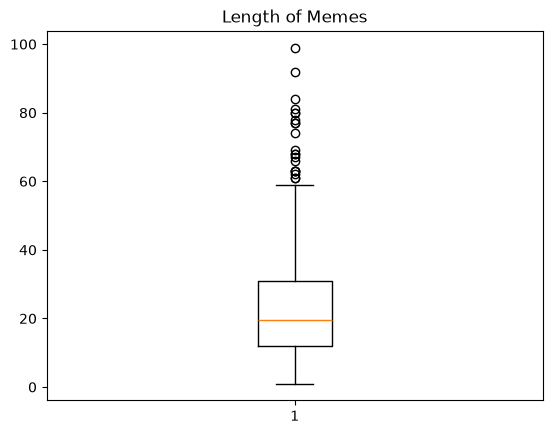

In [345]:
# Build vocabulary
all_train_tokens = [tokenizer.tokenize(t) for t in train_set_task1["text"]]
print(all_train_tokens[0])

# View the distribution of meme lengths according to our tokenizer.
plt.boxplot([len(train_token) for train_token in all_train_tokens])
plt.title("Length of Memes")

In [346]:
# Taken from Lab Week 8
encoded = tokenizer(
    "I am unbelievably happy",
    padding='max_length',
    truncation=True,
    max_length=12,
    return_tensors='pt'
)

print('Token IDs:      ', encoded['input_ids'][0].tolist())
print('Attention mask:  ', encoded['attention_mask'][0].tolist())
print('Decoded tokens:  ', tokenizer.convert_ids_to_tokens(encoded['input_ids'][0]))
print()
print('Notice:')
print('  - [CLS] at the start, [SEP] at the end')
print('  - "unbelievably" is split into subwords: un, ##believab, ##ly')
print('  - attention_mask is 1 for real tokens, 0 for padding')

Token IDs:       [101, 1045, 2572, 4895, 8671, 2666, 3567, 6321, 3407, 102, 0, 0]
Attention mask:   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
Decoded tokens:   ['[CLS]', 'i', 'am', 'un', '##bel', '##ie', '##va', '##bly', 'happy', '[SEP]', '[PAD]', '[PAD]']

Notice:
  - [CLS] at the start, [SEP] at the end
  - "unbelievably" is split into subwords: un, ##believab, ##ly
  - attention_mask is 1 for real tokens, 0 for padding


In [347]:
# Taken from Lab Week 8
class HFDataset(Dataset):
    """Dataset compatible with Hugging Face transformer models."""
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.labels = labels
        self.encodings = tokenizer(
            texts,
            padding='max_length',
            truncation=True,
            max_length=max_length,
            return_tensors='pt',
        )
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': torch.tensor(self.labels[idx], dtype=torch.float),
        }


task1_hf_train = HFDataset(train_set_task1["text"].to_list(), 
                           train_set_task1["label_encoded"], 
                           tokenizer,
                           MAX_LEN)
task1_hf_val = HFDataset(dev_set_task1["text"].to_list(), 
                           dev_set_task1["label_encoded"], 
                           tokenizer,
                           MAX_LEN)
task1_hf_test = HFDataset(test_set_task1["text"].to_list(), 
                           test_set_task1["label_encoded"], 
                           tokenizer,
                           MAX_LEN)

task1_hf_train_loader = DataLoader(task1_hf_train, batch_size=32, shuffle=True, generator=generator)
task1_hf_test_loader = DataLoader(task1_hf_test, batch_size=64, shuffle=False, generator=generator)
task1_hf_val_loader = DataLoader(task1_hf_val, batch_size=64, shuffle=False, generator=generator)

### Training the Model:

For training the model, we use AutoModelForSequenceClassification from the transformers library which allows us to take a pretrained transformer model and attach a classification head to the end so we can easily fit it for our task. I don't want to update the weights of the already good pretrained model so I freeze those layers and only let the classifier layer be trainable so we can fine tune it to predict labels for us. Due to the size and complexity of this model, training takes far longer than usual, and since we are only fine tuning the classifier head, we only need fewer epochs for training.

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 675.56it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2047138144.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.d

Step 1: Linear Probing
  Trainable: 605,972 / 66,968,852 (0.90%)
  [DistilBERT Uncased] Epoch 1/10 — Train: 1.1736 | Val: 1.4002
  [DistilBERT Uncased] Epoch 2/10 — Train: 1.1110 | Val: 1.3980
  [DistilBERT Uncased] Epoch 4/10 — Train: 1.0000 | Val: 1.3838
  [DistilBERT Uncased] Epoch 6/10 — Train: 0.9060 | Val: 1.3659
  [DistilBERT Uncased] Epoch 8/10 — Train: 0.8348 | Val: 1.3504
  [DistilBERT Uncased] Epoch 10/10 — Train: 0.7595 | Val: 1.4623


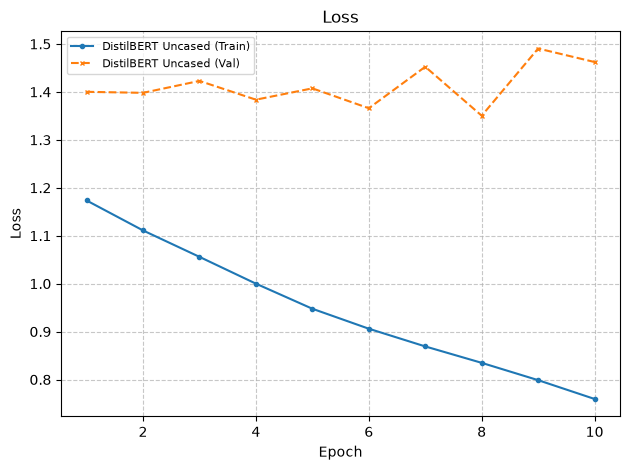

In [348]:
from transformers import AutoModelForSequenceClassification

# Use the pretrained DistilBERT uncased model.
torch.manual_seed(67)
distilbert = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(LABELS),
    problem_type="multi_label_classification",
    token=False
)

for param in distilbert.distilbert.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in distilbert.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in distilbert.parameters())
print(f'Step 1: Linear Probing')
print(f'  Trainable: {trainable:,} / {total_params:,} ({trainable/total_params*100:.2f}%)')

optimizer = optim.Adam(filter(lambda p: p.requires_grad, distilbert.parameters()), lr=5e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=task1_clamped_weights)

DistilBERT_Results = {}
DistilBERT_Results['DistilBERT Uncased'] = run_experiment(
    distilbert, optimizer, criterion, task1_hf_train_loader, task1_hf_val_loader,
    epochs=10, name='DistilBERT Uncased', tokenizer_mode=True, load_best_model=False
)

plot_experiments(DistilBERT_Results)

### Evaluating the Model:

This model easily outperforms the previous models. It has the highest total accuracy of 0.75, highest macro precision of 0.14, recall of 0.58, f1 of 0.2 and weighted precision 0.36, 0.74 and 0.44. A weighted recall of 0.74 and macro recall of 0.58 outperforms my initial naive target of recall. The only downsides is its rather small recall value and f1-score, however, they are not far from my initial target. 

Looking at the confusion matrices, False Positives still make up a large portion of errors within the predictions, however, these have decreased in several specific label cases. The most prominent example being in Appeal to Authority which in Dense Transformer had 71 false positives and 3 true positives, but now has 27 false positives and 4 true positives. It also does not fall into the same prediction collapse (aside from Red Herring) that we discovered in the clamped weights experiment, however, their precision and recalls are still 0. Another thing of note is Loaded Language which has increased in all 4 evaluation metrics (precision, recall f1-score and accuracy), it implies that for some of these classes these prelearned transformers are simply the better way of representing these tasks than our self made transformers can.

C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2047138144.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'labels': torch.tensor(self.labels[idx], dtype=torch.float),
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.2000      0.5714      0.2963           7      0.9050
Appeal to fear/preju         0.0909      0.5000      0.1538          10      0.7250
Black-and-white Fall         0.1064      0.7143      0.1852           7      0.7800
Causal Oversimplific         0.0385      0.3333      0.0690           3      0.8650
Doubt                        0.5000      0.3929      0.4400          28      0.8600
Exaggeration/Minimis         0.2045      0.4737      0.2857          19      0.7750
Flag-waving                  0.1389      0.8333      0.2381           6      0.8400
Glittering generalit         0.1064      0.4545      0.1724          11      0.7600
Loaded Language              0.7051      0.5500      0.6180         100      0.6600
Misrepresentation of         0.0270      1.0000      0.0526           1      0.8200
Name calling/Labelin         0.3585      0.3585      0.3585          53     

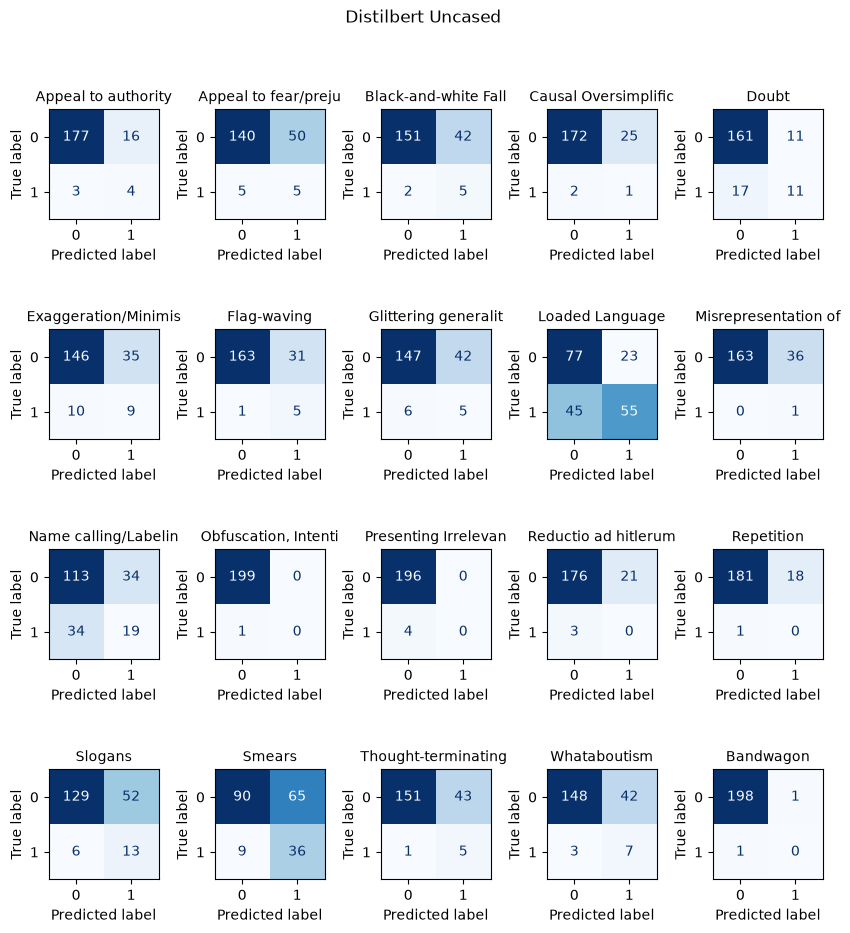

In [349]:
fig, report, accuracy = get_evaluation(distilbert, task1_hf_test_loader, "Distilbert Uncased", True)

view_report(report)
print(f"Total Accuracy: {accuracy}")

### Experiment 6: Distilbert Cased (REJECTED)

One of the things I noticed within the data is the major use of capitalization in order to vent frustration. "THERE ARE ONLY TWO GENDERS" for example is different to "there are only two genders" as the capitalization enhances the emotion of the text. Since we've only used the uncased tokenizer and transformer so far, I thought using a cased model might allow the model to learn based on these patterns. 

In [350]:
# Create a new tokenizer and dataset using the cased tokenizer.
cased_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-cased')

task1_hf_cased_train = HFDataset(train_set_task1["text"].to_list(), 
                           train_set_task1["label_encoded"], 
                           cased_tokenizer,
                           MAX_LEN)
task1_hf_cased_val = HFDataset(dev_set_task1["text"].to_list(), 
                           dev_set_task1["label_encoded"], 
                           cased_tokenizer,
                           MAX_LEN)
task1_hf_cased_test = HFDataset(test_set_task1["text"].to_list(), 
                           test_set_task1["label_encoded"], 
                           cased_tokenizer,
                           MAX_LEN)

task1_hf_cased_train_loader = DataLoader(task1_hf_cased_train, batch_size=32, shuffle=True, generator=generator)
task1_hf_cased_test_loader = DataLoader(task1_hf_cased_test, batch_size=64, shuffle=False, generator=generator)
task1_hf_cased_val_loader = DataLoader(task1_hf_cased_val, batch_size=64, shuffle=False, generator=generator)

### Training the Model:

Nothing of difference compared to DistilBERT-Uncased.

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 937.45it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2047138144.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.det

Step 1: Linear Probing
  Trainable: 605,972 / 65,796,884 (0.92%)
  [DistilBERT CASED] Epoch 1/10 — Train: 1.1978 | Val: 1.4434
  [DistilBERT CASED] Epoch 2/10 — Train: 1.1546 | Val: 1.4092
  [DistilBERT CASED] Epoch 4/10 — Train: 1.1299 | Val: 1.4130
  [DistilBERT CASED] Epoch 6/10 — Train: 1.1083 | Val: 1.3969
  [DistilBERT CASED] Epoch 8/10 — Train: 1.0740 | Val: 1.4706
  [DistilBERT CASED] Epoch 10/10 — Train: 1.0394 | Val: 1.4417


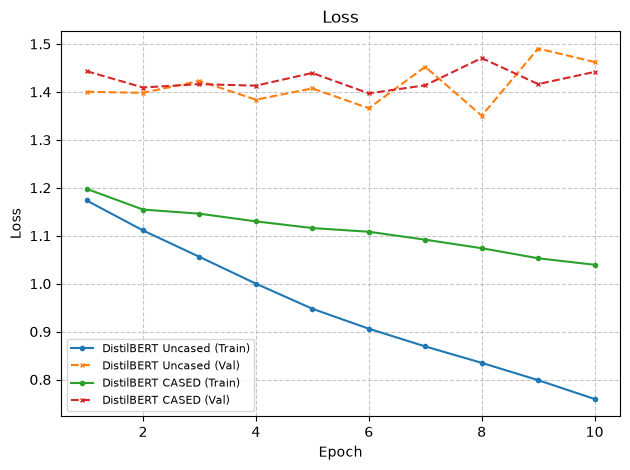

In [351]:
from transformers import AutoModelForSequenceClassification

torch.manual_seed(67)
distilbert_cased = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-cased',
    num_labels=len(LABELS),
    problem_type="multi_label_classification",
    token=False
)

for param in distilbert_cased.distilbert.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in distilbert_cased.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in distilbert_cased.parameters())
print(f'Step 1: Linear Probing')
print(f'  Trainable: {trainable:,} / {total_params:,} ({trainable/total_params*100:.2f}%)')

optimizer = optim.Adam(filter(lambda p: p.requires_grad, distilbert_cased.parameters()), lr=5e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=task1_clamped_weights)

DistilBERT_Results['DistilBERT CASED'] = run_experiment(
    distilbert_cased, optimizer, criterion, task1_hf_cased_train_loader, task1_hf_cased_val_loader,
    epochs=10, name='DistilBERT CASED', tokenizer_mode=True, load_best_model=False
)

plot_experiments(DistilBERT_Results)

### Evaluating the Model:

The model's overall evaluation metrics all underperform when compared to DistilBERT Uncased, with much lower precision, recall, f1-scores as well as overall accuracy. Prediction collapse is present within the severe minority labels and no label specific metrics (significantly) outperforms those shown in DistilBERT uncased. It implies that the significance of cased terms for this task does not substantially help with the classification task, because this DistilBERT Uncased outperforms this model in all metrics, I reject this model and choose DistilBERT uncased.

C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2047138144.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'labels': torch.tensor(self.labels[idx], dtype=torch.float),
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.0484      0.4286      0.0870           7      0.6850
Appeal to fear/preju         0.0538      0.5000      0.0971          10      0.5350
Black-and-white Fall         0.0588      1.0000      0.1111           7      0.4400
Causal Oversimplific         0.0194      1.0000      0.0380           3      0.2400
Doubt                        0.2432      0.6429      0.3529          28      0.6700
Exaggeration/Minimis         0.1284      0.7368      0.2188          19      0.5000
Flag-waving                  0.0312      0.5000      0.0588           6      0.5200
Glittering generalit         0.0758      0.9091      0.1399          11      0.3850
Loaded Language              0.5714      0.8400      0.6802         100      0.6050
Misrepresentation of         0.0120      1.0000      0.0238           1      0.5900
Name calling/Labelin         0.2866      0.8868      0.4332          53     

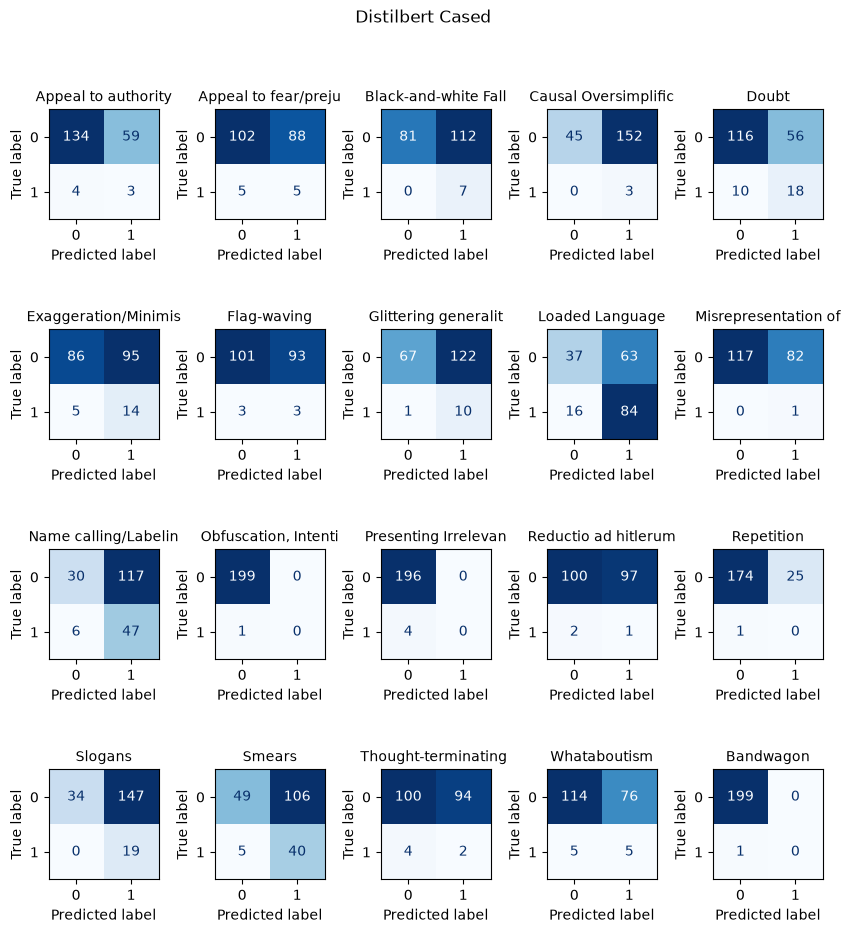

In [352]:
fig, report, accuracy = get_evaluation(distilbert_cased, task1_hf_cased_test_loader, "Distilbert Cased", True)

view_report(report)
print(f"Total Accuracy: {accuracy}")

### Experiment 7: LoRA

For my next experiment, I want to experiment with fine tuning the model using LoRA. LoRA is an adapter which we can add to our model to add a learned low rank update which is added to the model's existing frozen weights. The capacity of this low rank update is determined by the rank hyperparameter, where the higher r results in higher capacity. By updating the weights this way rather than updating all of the model's weights, it allows for model fine tuning without touching any of its initial weights, allowing us to save lots of computing costs while retaining most of fine-tuning's benefits.

I first run a test using the previous distilbert-uncased example to see which value for r will perform best for our task.

### Evaluating the Models:

All of the models follow a similar loss curve to each other with no clear signs of overfitting. 

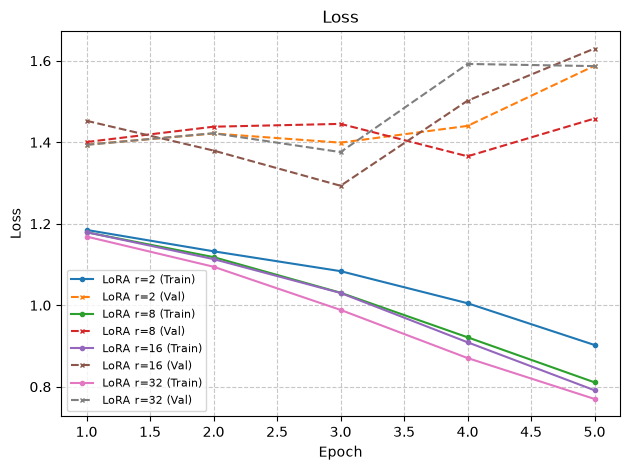

In [353]:

# How does the rank (r) affect performance?
lora_rank_results = {}
lora_rank_metrics = {}

for r in [2, 8, 16, 32]:
    print(f'\n--- LoRA r={r} ---')
    torch.manual_seed(67)
    base = AutoModelForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=len(LABELS), token=False
    ).to(device)
    
    config = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=r, lora_alpha=r*2,
        lora_dropout=0.1, target_modules=['q_lin', 'v_lin'],
    )
    peft_model = get_peft_model(base, config)
    peft_model.print_trainable_parameters()
    
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, peft_model.parameters()),
                            lr=5e-4, weight_decay=0.01)
    criterion = nn.BCEWithLogitsLoss(pos_weight=task1_clamped_weights)
    
    lora_rank_results[f'LoRA r={r}'] = run_experiment(
        peft_model, optimizer, criterion, task1_hf_train_loader, task1_hf_val_loader,
        epochs=5, name=f'LoRA r={r}', tokenizer_mode=True, load_best_model=False
    )
    
    fig, report, accuracy = get_evaluation(peft_model, task1_hf_val_loader, f"Lora Model (r={r})", tokenizer_mode=True)
    lora_rank_metrics[f'LoRA r={r}'] = {"fig" : fig, "report" : report, "accuracy" : accuracy}
    plt.close(fig)
    clear_output(True)
    
plot_experiments(lora_rank_results)

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.2000      1.0000      0.3333           2      0.8730
Appeal to fear/preju         0.3333      0.5000      0.4000           4      0.9048
Black-and-white Fall         0.0000      0.0000      0.0000           0      0.9048
Causal Oversimplific         0.0000      0.0000      0.0000           1      0.5714
Doubt                        0.1739      1.0000      0.2963           8      0.3968
Exaggeration/Minimis         0.1176      0.2857      0.1667           7      0.6825
Flag-waving                  0.2500      0.2000      0.2222           5      0.8889
Glittering generalit         0.1000      1.0000      0.1818           1      0.8571
Loaded Language              0.8889      0.2581      0.4000          31      0.6190
Misrepresentation of         0.1250      0.6667      0.2105           3      0.7619
Name calling/Labelin         0.5556      0.1724      0.2632          29     

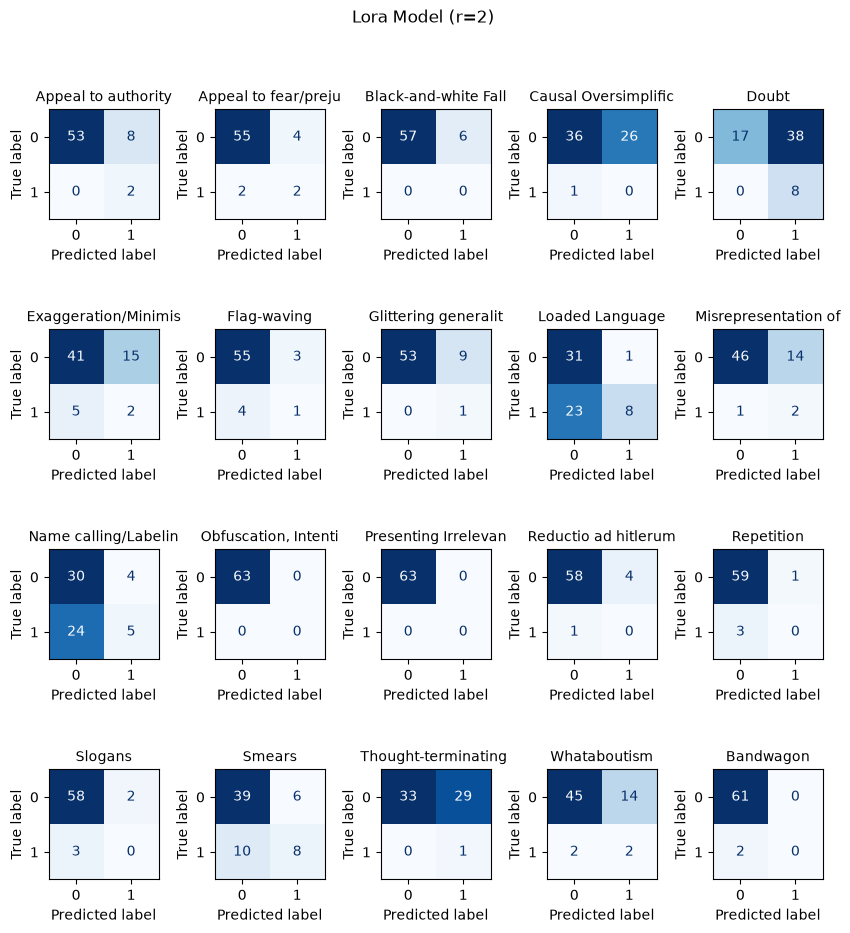

In [354]:
fig = lora_rank_metrics["LoRA r=2"]["fig"]
report = lora_rank_metrics["LoRA r=2"]["report"]
acc = lora_rank_metrics["LoRA r=2"]["accuracy"]

view_report(report)
print(f"Total Accuracy: {acc}")

display(fig)

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.1000      1.0000      0.1818           2      0.7143
Appeal to fear/preju         0.1579      0.7500      0.2609           4      0.7302
Black-and-white Fall         0.0000      0.0000      0.0000           0      0.7460
Causal Oversimplific         0.0000      0.0000      0.0000           1      0.6032
Doubt                        0.1250      0.5000      0.2000           8      0.4921
Exaggeration/Minimis         0.1176      0.2857      0.1667           7      0.6825
Flag-waving                  0.2500      0.8000      0.3810           5      0.7937
Glittering generalit         0.0500      1.0000      0.0952           1      0.6984
Loaded Language              0.7222      0.8387      0.7761          31      0.7619
Misrepresentation of         0.1364      1.0000      0.2400           3      0.6984
Name calling/Labelin         0.5952      0.8621      0.7042          29     

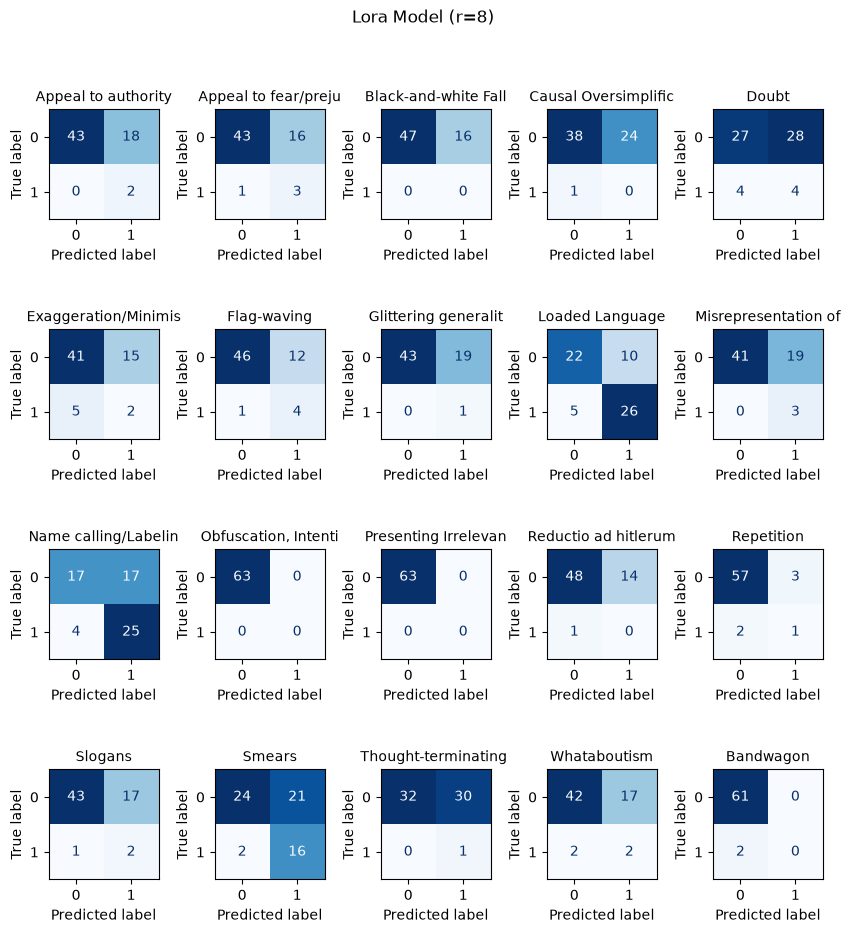

In [355]:
fig = lora_rank_metrics["LoRA r=8"]["fig"]
report = lora_rank_metrics["LoRA r=8"]["report"]
acc = lora_rank_metrics["LoRA r=8"]["accuracy"]

view_report(report)
print(f"Total Accuracy: {acc}")

display(fig)

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.1250      1.0000      0.2222           2      0.7778
Appeal to fear/preju         0.1364      0.7500      0.2308           4      0.6825
Black-and-white Fall         0.0000      0.0000      0.0000           0      0.8413
Causal Oversimplific         0.0000      0.0000      0.0000           1      0.8095
Doubt                        0.0870      0.2500      0.1290           8      0.5714
Exaggeration/Minimis         0.1379      0.5714      0.2222           7      0.5556
Flag-waving                  0.2353      0.8000      0.3636           5      0.7778
Glittering generalit         0.0526      1.0000      0.1000           1      0.7143
Loaded Language              0.7353      0.8065      0.7692          31      0.7619
Misrepresentation of         0.1818      0.6667      0.2857           3      0.8413
Name calling/Labelin         0.6190      0.8966      0.7324          29     

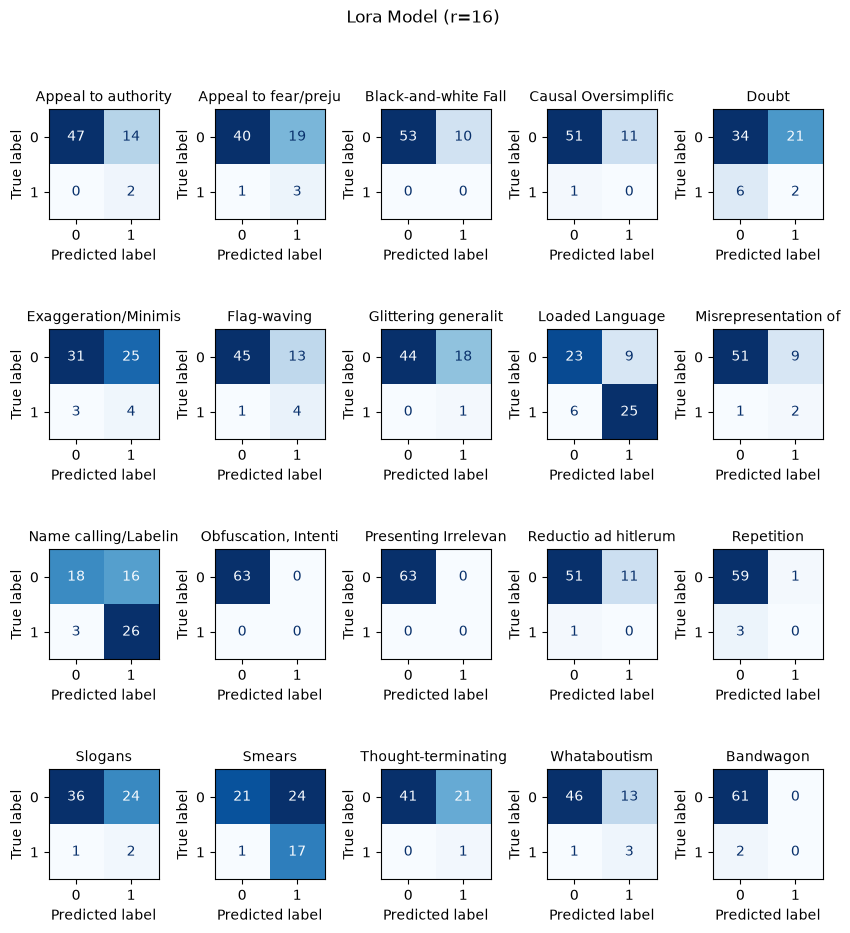

In [356]:
fig = lora_rank_metrics["LoRA r=16"]["fig"]
report = lora_rank_metrics["LoRA r=16"]["report"]
acc = lora_rank_metrics["LoRA r=16"]["accuracy"]

view_report(report)
print(f"Total Accuracy: {acc}")

display(fig)

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.2000      0.5000      0.2857           2      0.9206
Appeal to fear/preju         0.2500      0.7500      0.3750           4      0.8413
Black-and-white Fall         0.0000      0.0000      0.0000           0      0.8730
Causal Oversimplific         0.0000      0.0000      0.0000           1      0.6508
Doubt                        0.0909      0.2500      0.1333           8      0.5873
Exaggeration/Minimis         0.1667      0.2857      0.2105           7      0.7619
Flag-waving                  0.2727      0.6000      0.3750           5      0.8413
Glittering generalit         0.0667      1.0000      0.1250           1      0.7778
Loaded Language              0.7568      0.9032      0.8235          31      0.8095
Misrepresentation of         0.1538      0.6667      0.2500           3      0.8095
Name calling/Labelin         0.5833      0.7241      0.6462          29     

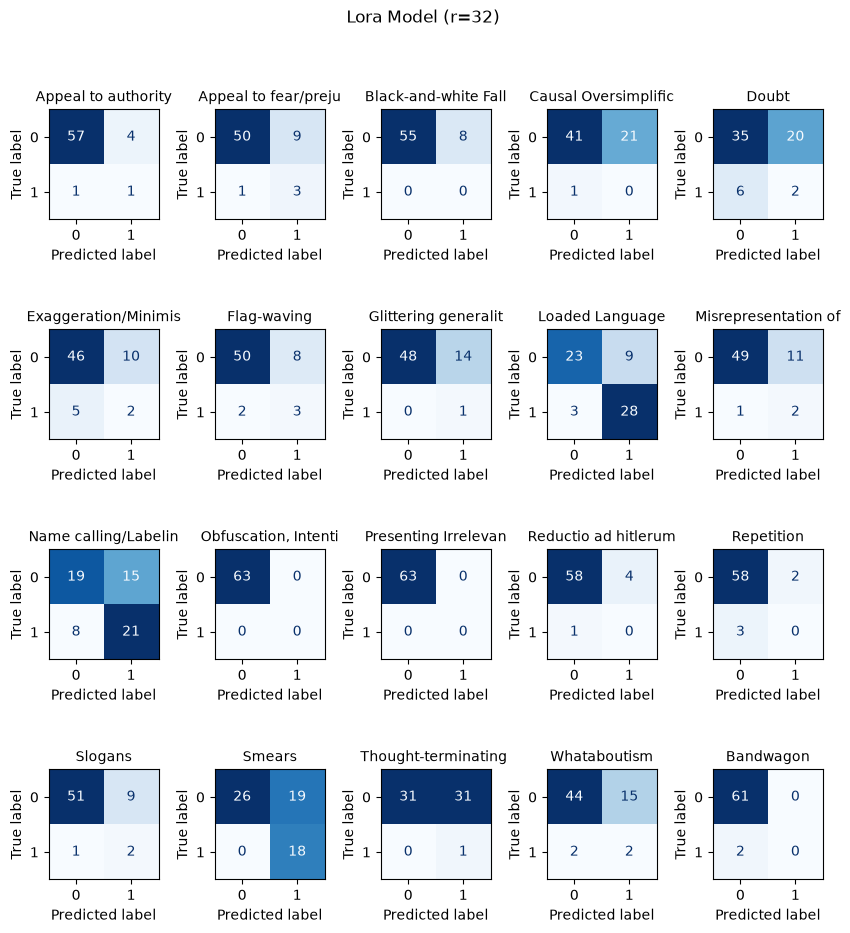

In [357]:
fig = lora_rank_metrics["LoRA r=32"]["fig"]
report = lora_rank_metrics["LoRA r=32"]["report"]
acc = lora_rank_metrics["LoRA r=32"]["accuracy"]

view_report(report)
print(f"Total Accuracy: {acc}")

display(fig)

### Evaluating R:

For ranks r=2 and r=8 there is not much difference between their evaluation metrics. Rank 8 has slightly better macro precision but slightly worse macro recall but their overall macro and weighted f1 scores, as well as total model accuracy are around the same level. Nothing too much of interest appears when looking at their confusion matrices, there seems to be significantly better results within the labels Name Calling, Smears, Exaggeration for rank 8 over rank 2 for per label accuracy and precision. But Rank 2 seems to have better results for the labels Causal Oversimplifcation and Doubt, with better accuracies and precision.

At r=16 we see that the model performs worse than the r=8 model in every metric, except for total model accuracy which has increased from 0.748 to 0.808. Looking at the confusion matrices we can attribute this to the fact that the model seems to predict negative samples much more often than it did in r=8, leading to overall much worse recall which has decreased from macro 0.526 to 0.467 and weighted 0.691 to 0.634. In every single label, the number of true positives (or even positive labelled) have all decreased, this is somewhat similar to maintaining the same model but increasing the probability threshold, although one performance metric has increased, it does not indicate that there is actual learning.

At r=32 the model improves from the r=16 model and has somewhat similar performance to r=8 which was our previous best model. It only has minor decreases from precision, recall, f1 and total accuracy, but are still within a very reasonable margin. Interestingly, weighted recall has actually increased from 0.691 to 0.756. Three labels have notable increases in recall from r=8: Smears and Name Calling (which has the biggest increase of 0.586 to 0.828). Within other labels, recall seems to be at an equal level, with some slight increases or slight decreases. I also notice that unlike r=16's performance, r=32 seems to show evidence of actual learning to the problem, as there are signs within the confusion matrices that the tradeoff between labelling positive / negative happen because of the way the model actually encodes / interprets the text. For example, one of the things I mentioned for r=16 is that the increase in accuracy only happens because the model seems to JUST predict negative samples more often, similar to increasing the probability thresholds of the same model which does not seem to be the case in r=32.

Overall, I decide to choose r=32 as my final rank parameter. Despite r=8's marginal better overall metrics, r=32 seems to be better for our task overall, with an increased weighted recall which is what I wanted to prioritize for the model.

## Final Model

I will be using the Distilbert-uncased model with a LoRA adapter with rank = 32 for my final model for this task. I will also tune the probability thresholds to further improve its capabilities.

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 746.16it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2047138144.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.d

  [LoRA r=32] Epoch 1/5 — Train: 1.1840 | Val: 1.4140
  [LoRA r=32] Epoch 2/5 — Train: 1.1072 | Val: 1.3843
  [LoRA r=32] Epoch 3/5 — Train: 1.0034 | Val: 1.3734
  [LoRA r=32] Epoch 4/5 — Train: 0.8720 | Val: 1.3451
  [LoRA r=32] Epoch 5/5 — Train: 0.7615 | Val: 1.7588


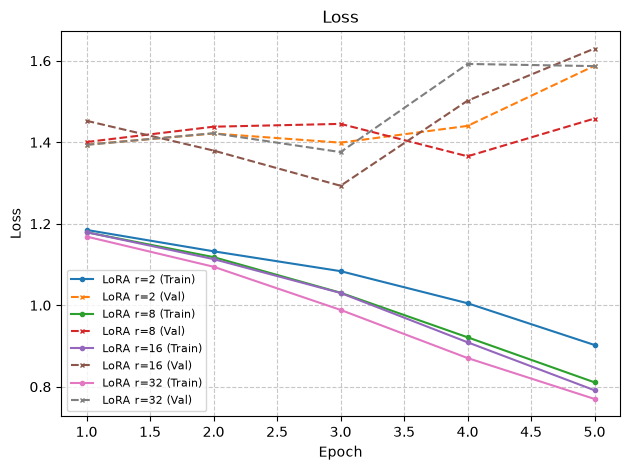

In [358]:
torch.manual_seed(67)
base = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=len(LABELS), token=False
).to(device)

config = LoraConfig(
    task_type=TaskType.SEQ_CLS, r=32, lora_alpha=r*2,
    lora_dropout=0.1, target_modules=['q_lin', 'v_lin'],
)
final_task1_model = get_peft_model(base, config)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, final_task1_model.parameters()),
                        lr=5e-4, weight_decay=0.01)
criterion = nn.BCEWithLogitsLoss(pos_weight=task1_clamped_weights)

run_experiment(
    final_task1_model, optimizer, criterion, task1_hf_train_loader, task1_hf_val_loader,
    epochs=5, name=f'LoRA r={r}', tokenizer_mode=True, load_best_model=False
)

plot_experiments(lora_rank_results)

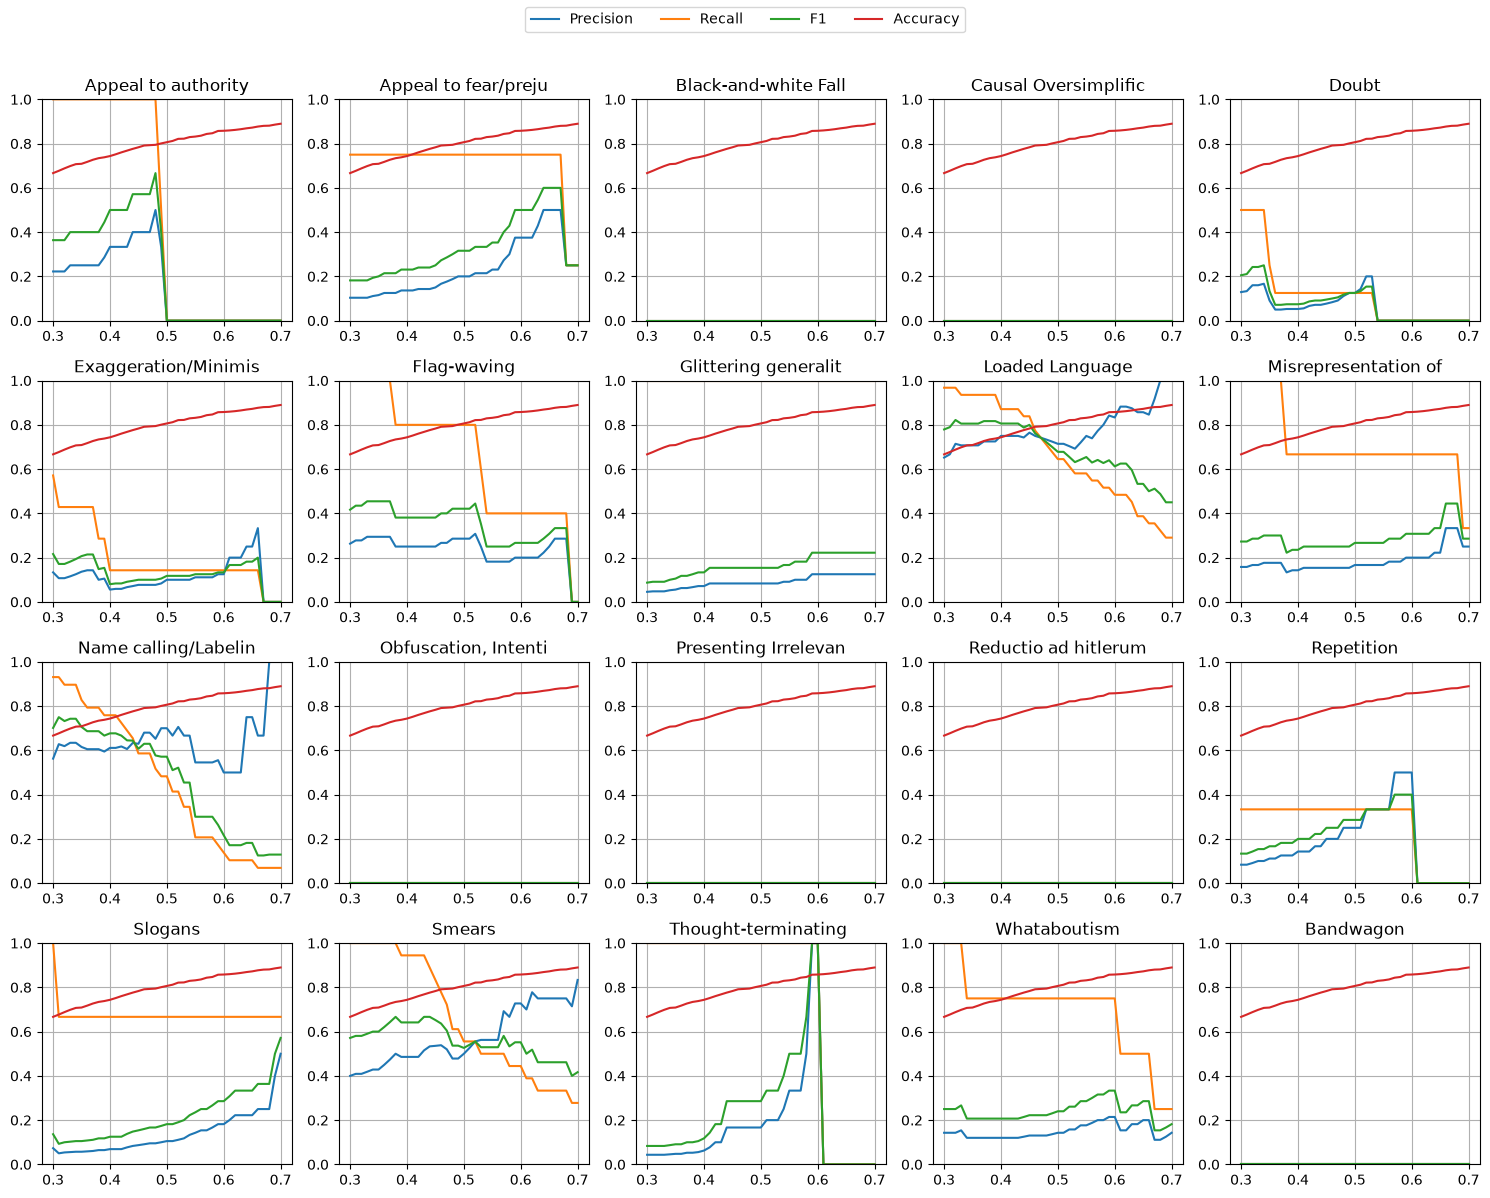

In [359]:
fig, ax = plt.subplots(4, 5, figsize=(15, 12))

for i, label in enumerate(LABELS):
    thresholds, precisions, recalls, f1_scores, accuracies = threshold_testing(label, final_task1_model, task1_hf_val_loader, True)
    clear_output(True)

    current_ax = ax[i // 5, i % 5]

    current_ax.plot(thresholds, precisions, label="Precision")
    current_ax.plot(thresholds, recalls, label="Recall")
    current_ax.plot(thresholds, f1_scores, label="F1")
    current_ax.plot(thresholds, accuracies, label="Accuracy")

    current_ax.set_title(label[:20])
    current_ax.set_ylim(0, 1)
    current_ax.grid()
    
# Legends
handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [360]:
THRESHOLDS = [0.5 for i in range(len(LABELS))]

THRESHOLDS[LABELS.index("Appeal to fear/prejudice")] = 0.65
THRESHOLDS[LABELS.index("Exaggeration/Minimisation")] = 0.4
THRESHOLDS[LABELS.index("Name calling/Labeling")] = 0.6
THRESHOLDS[LABELS.index("Loaded Language")] = 0.55
THRESHOLDS[LABELS.index("Smears")] = 0.6
THRESHOLDS[LABELS.index("Thought-terminating cliché")] = 0.6

### Evaluating Final Model:

As a naive estimate from creating the evaluation metric, I had set estimated goals for:
1. Macro Recall: ~0.5
2. Weighted Recall: ~0.65
3. Macro F1: ~0.5
4. Weighted F1: ~0.5

For our final model we have:
1. Macro Recall: 0.572
2. Weighted Recall: 0.633
3. Macro F1: 0.205
4. Weighted F1: 0.444

We have achieved our naive goals for both macro and weighted recall and slightly undershoot our target weighted f1 score. However, macro F1 is extremely low compared to our target. I deem this fine because most of the low F1-Score comes at a cost of a precision of 0 on some of our extreme minority labels, such as Obfuscation, Red Herring and Bandwagon. Furthermore, as I mentioned previously, precision is a fickle metric, especially for this kind of data specifically because of its nature. Since a meme has no "true" answer for what techniques it may use, as it is up to interpretation, and in this data, the interpretation of human researchers. It is expected that there will be a lot of samples that we flag as false positive for some technique. What is important at the end of the day for our task is not a strict, "this meme uses THESE SPECIFIC techniques", but be a vague outliner for an operator, such as a teacher to be able to take our machine's interpretations and try to relay them back to an audience. 

C:\Users\Bop\AppData\Local\Temp\ipykernel_36848\2047138144.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'labels': torch.tensor(self.labels[idx], dtype=torch.float),
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bop\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

                          precision      recall    f1-score     support    accuracy
Appeal to authority          0.4286      0.4286      0.4286           7      0.9600
Appeal to fear/preju         0.1053      0.2000      0.1379          10      0.8750
Black-and-white Fall         0.0805      1.0000      0.1489           7      0.6000
Causal Oversimplific         0.0250      0.3333      0.0465           3      0.7950
Doubt                        0.4412      0.5357      0.4839          28      0.8400
Exaggeration/Minimis         0.2083      0.5263      0.2985          19      0.7650
Flag-waving                  0.1333      0.6667      0.2222           6      0.8600
Glittering generalit         0.1481      0.3636      0.2105          11      0.8500
Loaded Language              0.7797      0.4600      0.5786         100      0.6650
Misrepresentation of         0.0345      1.0000      0.0667           1      0.8600
Name calling/Labelin         0.6471      0.2075      0.3143          53     

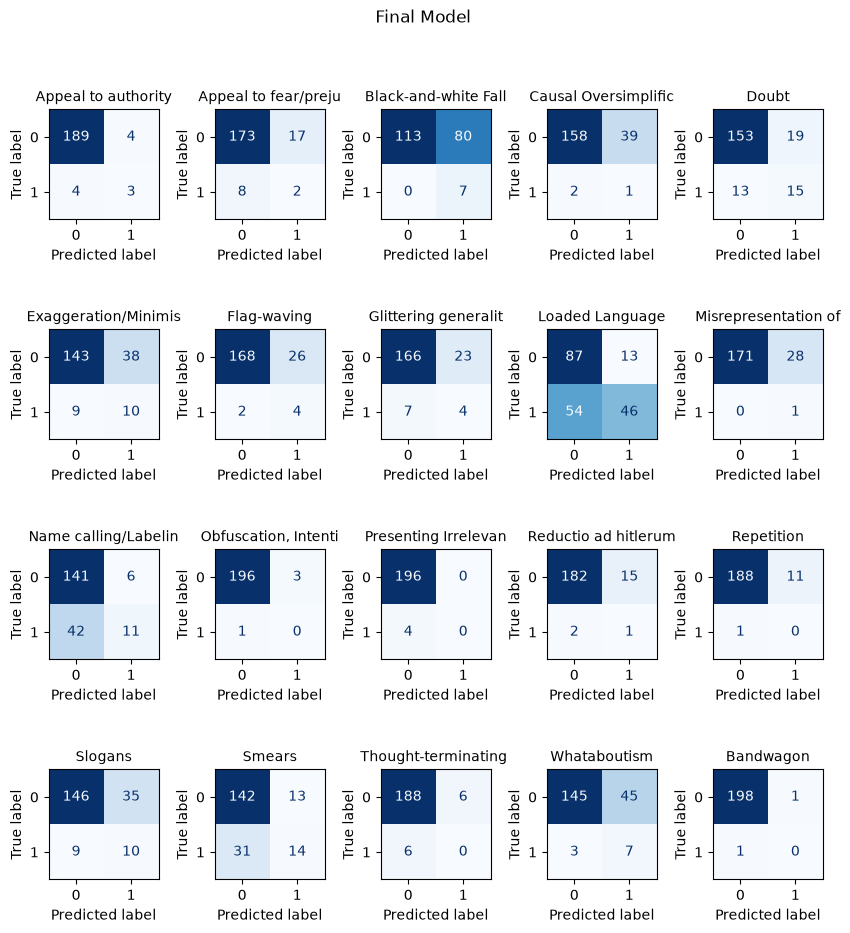

In [361]:
fig, report, accuracy = get_evaluation(final_task1_model, task1_hf_test_loader, "Final Model", tokenizer_mode=True, prob_thresholds=THRESHOLDS)
view_report(report)
print(f"Total Accuracy: {accuracy}")

# Task 2

For Task 2, we would like to go one step further by classifying the span of text which is responsible for the flagged technique. I plan to accomplish this by creating a new classifier model which will take in inputs: technique used and text. Then output the span labels. The technique labelling will come using the model that I have made from Task 1.  

## Plan:

I intend to solve this task by creating a new "span classification" model for Task 2 which will act as a classifier head that takes an input from Task 1 in order to do its calculations.

## The Data:

We can view the way that our dataset handles the data. For each meme it stores a list of dictionaries instead of a simple label from Task 1. Within each dictionary it contains the technique that was used, the starting character position in the string and a ending character position which indicates the span of text that flagged the technique. 

What's important to see is that one meme can contain duplicate techniques. In the meme: 

"SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?
POWER COMES FROM THE BARREL OF A GUN, COMRADES.
WHAT ABOUT THE ONE WHO SHOT CONGRESSMAN SCALISE OR THE DAYTON OHIO MASS SHOOTER?"

Three seperate spans of texts all pointed to Loaded Language, with "Violence", "MASS SHOOTER" and "COMRADES".

In [362]:
# Check a sample of how the data structures a span
train_set_task2["labels"].iloc[0]

[{'start': 0,
  'end': 41,
  'technique': 'Black-and-white Fallacy/Dictatorship',
  'text_fragment': 'THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE'}]

In [363]:
# Check to see if within one meme, there can be multiple spans that point to the same technique. 
duplicates = []
duplicate_text = []
for text, annotation in zip(train_set_task2["text"], train_set_task2["labels"]):
    techniques_used = [label["technique"] for label in annotation]
    if len(techniques_used) != len(set(techniques_used)):
        duplicates.append(annotation)
        duplicate_text.append(text)

print(duplicates[0])
print(duplicate_text[0])

[{'end': 83, 'start': 47, 'technique': 'Slogans', 'text_fragment': 'POWER COMES FROM THE BARREL OF A GUN'}, {'end': 14, 'start': 3, 'technique': 'Name calling/Labeling', 'text_fragment': 'BERNIE BROS'}, {'end': 41, 'start': 33, 'technique': 'Loaded Language', 'text_fragment': 'VIOLENCE'}, {'end': 175, 'start': 163, 'technique': 'Loaded Language', 'text_fragment': 'MASS SHOOTER'}, {'end': 93, 'start': 85, 'technique': 'Loaded Language', 'text_fragment': 'COMRADES'}, {'end': 176, 'start': 0, 'technique': 'Smears', 'text_fragment': "SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\n\nPOWER COMES FROM THE BARREL OF A GUN, COMRADES.\n\nWHAT ABOUT THE ONE WHO SHOT CONGRESSMAN SCALISE OR THE DAYTON OHIO MASS SHOOTER?"}]
SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?

POWER COMES FROM THE BARREL OF A GUN, COMRADES.

WHAT ABOUT THE ONE WHO SHOT CONGRESSMAN SCALISE OR THE DAYTON OHIO MASS SHOOTER?



## Preparations

To prepare for Task 2, I need to modify some training / evaluation fucntions and create the dataset object.

In [364]:
class Task2Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.span_labels = [] # Contains a tensor of shape (max_len, 20) which represents the technique used present in each token.
        self.technique_labels = [] # Acts as self.labels from Task 1. Contains all techniques used in the meme
        self.offset_mappings = [] # Used to keep offset mapping from tokenizer so we can map the indices to tokens for classification later.
        self.texts = texts
        self.text_fragments = [] # Contains the span of text that flags a technique
        self.encodings = []
        self.lengths = []

        for text, annotations in zip(texts, labels):
            encodings = tokenizer(
                        text,
                        padding='max_length',
                        truncation=True,
                        max_length=max_len,
                        return_offsets_mapping=True
                    )
            
            offsets = encodings["offset_mapping"]
            span_targets = torch.zeros((max_len, len(LABELS)), dtype=torch.float)
            
            technique_targets = torch.zeros(len(LABELS), dtype=torch.float)
            
            fragments = []
            
            for annotation in annotations:
                label_idx = LABELS.index(annotation["technique"])
                char_start = annotation["start"]
                char_end = annotation["end"]
                
                technique_targets[label_idx] = 1.0
                fragments.append(annotation["text_fragment"])
                
                # Using the start and end keys in each span, set the value of 
                # meme[start:end][technique] = 1 in its span vector.
                for token_idx, (token_start, token_end) in enumerate(offsets):
                    if token_end > char_start and token_start < char_end:
                        span_targets[token_idx, label_idx] = 1.0
            
            # Span labels are of shape (max_len, num_labels)
            self.span_labels.append(span_targets)
            self.technique_labels.append(technique_targets)
            self.offset_mappings.append(offsets)
            self.text_fragments.append(fragments)
            self.encodings.append(encodings)
            self.lengths.append(sum(encodings["attention_mask"]) - 2)
            
    def __len__(self):
        return len(self.encodings)
    
    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.encodings[idx]['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(self.encodings[idx]['attention_mask'], dtype=torch.long),
            'spans': self.span_labels[idx],
            'labels': self.technique_labels[idx],
            'text': self.texts[idx],
            'index':idx,
            'lengths': self.lengths[idx]
        }

In [365]:
task2_train_ds = Task2Dataset(train_set_task2["text"], train_set_task2["labels"], tokenizer)
task2_val_ds = Task2Dataset(dev_set_task2["text"], dev_set_task2["labels"], tokenizer)
task2_test_ds = Task2Dataset(test_set_task2["text"], test_set_task2["labels"], tokenizer)

task2_train_loader = DataLoader(task2_train_ds, batch_size=128, shuffle=True, generator=generator)
task2_val_loader = DataLoader(task2_val_ds, batch_size=256, shuffle=False, generator=generator)
task2_test_loader = DataLoader(task2_test_ds, batch_size=256, shuffle=False, generator=generator)

I also want to study the distribution of span lengths in the data. It seems that most of the data has quite short spans for each label. With most having ~5 tokens in length. However, there are many outliers with span lengths up to ~80. Inspecting the training data itself, it seems like some of the spans just cover the entire meme, which is where these long spans come from.

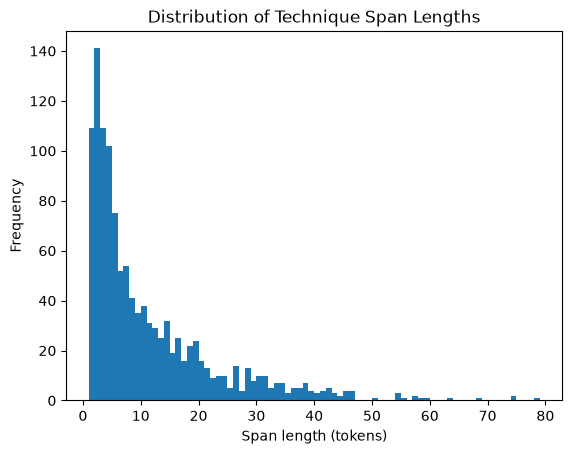

In [366]:
span_lengths = []
for i in range(len(task2_train_ds)):
    spans = task2_train_ds[i]["spans"]
    
    for label_idx in range(spans.shape[1]):
        length = spans[:, label_idx].sum().item()
        
        if length > 0:
            span_lengths.append(int(length))

plt.hist(span_lengths, bins=range(1, max(span_lengths) + 2))
plt.xlabel("Span length (tokens)")
plt.ylabel("Frequency")
plt.title("Distribution of Technique Span Lengths")
plt.show()

## Training Strategy:

To train the model I think it would be apt to train our Task 2 model using the ground truths from the training set, rather than directly using Task 1 model's outputs as an input for the Task 2 model in training. I do this because the latter option heavily relies on the performance of Task 1's model. Even if Task 1's model has an 80% recall per label, thats still ~20% of training data that is lost. 

## Evaluation Metric:

For this specific task, simple model-agnostic evaluation metrics such as simple accuracy, precision and recall will not be enough for this task. Although these metrics can help, the best method of evaluating the model is to view its outputted spans, which I will use as a primary method of evaluating the model.

A good naive benchmark that I would like to set is that:
1. The classifier, when told that "X Technique is being used" WILL span a text as being the flagger.

2. The classifier will not span texts for techniques which we do not say are being part of its used techniques. E.g if the model flags a span of text as using technique Y when we tell it that Y is not being used in this meme, it is incorrect.

3. The classifier, given that it was inputted the correct techniques, should span at least one subsection contained within the actual span. E.g if a meme has spanned "This spans Loaded Language", the model should ideally create a span which contains at least some part of this span, like "spans Loaded Language". 

EXTRA NOTE: For markers, one of my evaluation metrics that I use, write_examples(), actually writes out its results into a seperate text file, rather than print it out onto the console. I found this to be preferable because of the sheer size of the print message, which would be difficult to read directly in the console. Although this MAY be an infridgement of the technical requirement: "All decision-supporting figures must be embedded in the notebook". I found this to be the easiest method of using this custom function. I have embedded screenshots of relevant excerpts from each file into the document, however, if you wish to view the actual text file, you may either run the code block to generate that file, or print it out in the notebook. I shall create code blocks for either option.

In [367]:
task2_example_set = {}

for example in task2_test_ds:
    for label_index, val in enumerate(example["labels"]):
        if not val:
            continue
        
        technique = LABELS[label_index]
        
        task2_example_set.setdefault(technique, []).append(example)

In [368]:
def evaluate_task2(model, loader, num_examples=1):
    """
    Task 2 equivalent of evaluate_model() in task 1.
    """
    model.eval()

    total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0
    total_loss, total = 0.0, 0
    examples = []

    with torch.inference_mode():
        for batch in loader:

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            spans = batch['spans'].to(device)
            techniques = batch['labels'].to(device)

            logits = model(input_ids, attention_mask, techniques)

            # Get rid of the positions for [CLS] and [SEP] 
            spans = spans[:, 1:-1, :]
            attention_mask = attention_mask[:, 1:-1]
            
            loss = criterion(logits, spans)

            mask = attention_mask.unsqueeze(-1)
            
            # Get the mean loss
            loss = (loss * mask).sum() / mask.expand_as(loss).sum()

            total_loss += loss.item() * input_ids.size(0)
            total += input_ids.size(0)

            # Creates probabilities and converts them to boolean signals
            probabilities = torch.sigmoid(logits)
            predicted_spans = probabilities >= 0.5

            # Calculate metrics
            metric_mask = mask.bool()

            tp = predicted_spans & (spans == 1) & metric_mask
            fp = predicted_spans & (spans == 0) & metric_mask
            fn = (~predicted_spans) & (spans == 1) & metric_mask
            tn = (~predicted_spans) & (spans == 0) & metric_mask
            
            total_tp += tp.sum().item()
            total_fp += fp.sum().item()
            total_fn += fn.sum().item()
            total_tn += tn.sum().item()
        
        # Save examples
        for technique in LABELS:
            # Looks through our set of examples and saves model outputs to a dictionary
            example_set = task2_example_set[technique]
            for i in range(min(num_examples, len(example_set))):
                example = example_set[i]
                
                input_ids = example['input_ids'].unsqueeze(0).to(device)
                attention_mask = example['attention_mask'].unsqueeze(0).to(device)
                spans = example['spans'].unsqueeze(0).to(device)
                techniques = example['labels'].unsqueeze(0).to(device)

                logits = model(input_ids, attention_mask, techniques)

                spans = spans[:, 1:-1, :]
                attention_mask = attention_mask[:, 1:-1]
                
                probabilities = torch.sigmoid(logits)
                predicted_spans = probabilities >= 0.5

                # Convert to lists for easier handling
                predicted_spans_list = predicted_spans.squeeze(0).cpu().numpy().tolist()
                true_spans_list = spans.squeeze(0).cpu().numpy().tolist()

                examples.append({
                    "text": example["text"],
                    "predicted_spans": predicted_spans_list,
                    "true_spans": true_spans_list,
                    "labels": techniques
                })
    
    # Calculate macro metrics for the model.
    precision = total_tp / (total_tp + total_fp) if total_tp + total_fp > 0 else 0
    recall = total_tp / (total_tp + total_fn) if total_tp + total_fn > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0 else 0
    )
    accuracy = (
        (total_tp + total_tn) /
        (total_tp + total_fp + total_fn + total_tn)
        if total_tp + total_fp + total_fn + total_tn > 0 else 0
    )

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "loss": total_loss / total
    }

    return metrics, examples

In [369]:
def train_one_epoch_task2(model, loader, optimizer, criterion):
    """
    Task 2 equivalent of train_one_epoch in Task 1.
    """
    
    model.train()
    
    total_loss, total = 0.0, 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        spans = batch['spans'].to(device)
        techniques = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        logits = model(input_ids, attention_mask, techniques)
        
        # Get rid of positions for [CLS] and [SEP]
        spans = spans[:, 1:-1, :]
        attention_mask = attention_mask[:, 1:-1]
        
        loss = criterion(logits, spans)
        
        mask = attention_mask.unsqueeze(-1)
        
        # Get the mean loss
        loss = (loss * mask).sum() / mask.expand_as(loss).sum()
        
        loss.backward()
        
        optimizer.step()
        
        total_loss += loss.item() * input_ids.size(0)
        total += input_ids.size(0)
    
    return total_loss / total

def run_experiment_task2(model, optimizer, criterion, train_loader, val_loader, 
                         epochs=10, name='Model', load_best_model=True):
    """
    Task 2 equivalent of run_experiment in Task 1
    """
    
    history = {'train_loss': [], 'val_loss': []}
    best_model = None
    best_loss = float('inf')
    
    for epoch in range(epochs):
        train_loss = train_one_epoch_task2(model, train_loader, optimizer, criterion)
        val_loss = evaluate_task2(model, val_loader)[0]['loss']
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model.state_dict())
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        if (epoch + 1) % max(1, epochs // 5) == 0 or epoch == 0:
            print(f'  [{name}] Epoch {epoch+1}/{epochs} — '
                    f'Train: {train_loss:.4f} | Val: {val_loss:.4f}')
        
    
    if best_model is not None and load_best_model:
        model.load_state_dict(best_model)
    
    return history

In [493]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def write_examples(examples, write_path="test.txt", to_console = False, skip_unflagged_labels=True):
    """
    Custom Evaluation function. Takes a set of examples and writes our model's predicted spans and their true spans to a seperate file.
    skip_unflagged_labels controls whether we print out the evaluation metrics for the unflagged labels.
    E.g if the true labels for a meme is X and Y, we can choose whether to see the metrics for Z.
    Might be useful for the final model, when we can make mistakes in choosing which techniques are being used.
    """
    
    with open(write_path, "w") as f:
        for id, example in enumerate(examples):
            f.write("--------------------------------------------------\n")
            f.write("--------------------------------------------------\n")
            f.write(f"Example ID: {id}\n")
            
            tokens = tokenizer(
                        example["text"],
                        padding='max_length',
                        truncation=True,
                        max_length=64,
                        return_offsets_mapping=True
                    )
            
            tokens = tokenizer.convert_ids_to_tokens(tokens["input_ids"])
            tokens = tokens[1:-1]
            
            true_spans = np.array(example["true_spans"])
            predicted_spans = np.array(example["predicted_spans"])
            
            f.write(f"Text:\n{example["text"]}\n")
            f.write("\n")
            
            f.write("--------------------------------------------------\n")
            f.write("True Techniques:\n")
            for technique_index, value in enumerate(example["labels"][0]):
                if value:
                    f.write(f"- {LABELS[technique_index]}\n")
            f.write("\n")
            f.write("--------------------------------------------------\n")
            f.write("Spanned Techniques:\n")
            for technique_index, value in enumerate(LABELS):
                if True in predicted_spans[:, technique_index]:
                    f.write(f"- {value}\n")
            
            f.write("--------------------------------------------------\n")
            f.write("Predicted Spans:\n")
            
            # Writes out the Predicted Spans
            start_idx = [-1 for i in range(20)]
            for token_index, row in enumerate(predicted_spans):
                for technique_index, value in enumerate(row):
                    # For each token index, check if the value in the span is 0 or 1.
                    # If its 1:
                    #   - Check if we've opened a span already.
                    #   - If a span is already opened:
                    #       - Ignore it
                    #   - Else:
                    #       - Open a span and remember this index as the "start"
                    # If its 0:
                    #   - Check if we have an open span
                    #   - If we do:
                    #       - Close the span and set the index before this as the end_index, then writes it out.
                    #   - Else:
                    #       - Ignore it
                    if value:
                        if start_idx[technique_index] == -1:
                            start_idx[technique_index] = token_index
                    else:
                        if start_idx[technique_index] != -1:
                            technique_start_index = start_idx[technique_index]
                            technique_end_index = token_index
                            
                            f.write(" ".join(tokens[technique_start_index:technique_end_index]))
                            f.write("\n")
                            
                            f.write(f"Technique: {LABELS[technique_index]}\nStart: {technique_start_index}\nEnd: {technique_end_index}\n")
                            start_idx[technique_index] = -1
            
            # Closes out unclosed spans (not unclosed by the model, but unclosed by our detection loop).
            for technique_index in range(len(LABELS)):
                if start_idx[technique_index] != -1:
                    technique_start_index = start_idx[technique_index]
                    technique_end_index = len(predicted_spans) - 1
                    
                    f.write(" ".join(example["text"].split()[technique_start_index:technique_end_index]))
                    f.write("\n")
                                                
                    f.write(f"Technique: {LABELS[technique_index]}\nStart: {technique_start_index}\nEnd: {technique_end_index}\n")
            
            f.write("--------------------------------------------------\n")
            f.write("\n")
            f.write("True Spans:\n")
            
            # Writes out the True Spans
            start_idx = [-1 for i in range(20)]
            for token_index, row in enumerate(true_spans):
                for technique_index, value in enumerate(row):
                    # For each token index, check if the value in the span is 0 or 1.
                    # If its 1:
                    #   - Check if we've opened a span already.
                    #   - If a span is already opened:
                    #       - Ignore it
                    #   - Else:
                    #       - Open a span and remember this index as the "start"
                    # If its 0:
                    #   - Check if we have an open span
                    #   - If we do:
                    #       - Close the span and set the index before this as the end_index, then writes it out.
                    #   - Else:
                    #       - Ignore it
                    if value:
                        if start_idx[technique_index] == -1:
                            start_idx[technique_index] = token_index
                    else:
                        if start_idx[technique_index] != -1:
                            technique_start_index = start_idx[technique_index]
                            technique_end_index = token_index
                            
                            f.write(" ".join(tokens[technique_start_index:technique_end_index]))
                            f.write("\n")
                            
                            f.write(f"Technique: {LABELS[technique_index]}\nStart: {technique_start_index}\nEnd: {technique_end_index}\n")
                            start_idx[technique_index] = -1
            
            # Closes out unclosed spans (not unclosed by the model, but unclosed by our detection loop).
            for technique_index in range(len(LABELS)):
                if start_idx[technique_index] != -1:
                    technique_start_index = start_idx[technique_index]
                    technique_end_index = len(true_spans) - 1
                    
                    f.write(" ".join(example["text"].split()[technique_start_index:technique_end_index]))
                    f.write("\n")
                    
                    f.write(f"Technique: {LABELS[technique_index]}\nStart: {technique_start_index}\nEnd: {technique_end_index}\n")

            f.write("--------------------------------------------------\n")
            f.write("\n")

            true_spans = np.array(true_spans)
            predicted_spans = np.array(predicted_spans)
            
            # Writes out the per-label evaluation metrics.
            for technique_index, technique in enumerate(LABELS):
                if skip_unflagged_labels and not example["labels"][0][technique_index].sum():
                    continue
                
                true_label = true_spans[:, technique_index]
                predicted_label = predicted_spans[:, technique_index]
                
                f.write(f"LABEL: {technique}\n")
                f.write(f"Accuracy: {accuracy_score(true_label, predicted_label) :.3f}\n")
                f.write(f"Precision: {precision_score(true_label, predicted_label, zero_division=0) :.3f}\n")
                f.write(f"Recall: {recall_score(true_label, predicted_label, zero_division=0) :.3f}\n")
                f.write(f"F1: {f1_score(true_label, predicted_label, zero_division=0) :.3f}\n")
                f.write("\n")
            
            # Writes out the overall macro metrics. 
            f.write("--------------------------------------------------\n")
            f.write(f"Macro Metrics:\n")
            f.write(f"Accuracy: {accuracy_score(true_spans, predicted_spans) :.3f}\n")
            f.write(f"Macro Precision: {precision_score(true_spans, predicted_spans, zero_division=0, average='macro') :.3f}\n")
            f.write(f"Macro Recall: {recall_score(true_spans, predicted_spans, zero_division=0, average='macro') :.3f}\n")
            f.write(f"Macro F1: {f1_score(true_spans, predicted_spans, zero_division=0, average='macro') :.3f}\n")
            f.write("\n")
    
    if to_console:
        with open(write_path, "r") as f:
            print(f.read())

## Building the Model

### Baseline Model:

For my baseline model, I decide to just use one incredibly basic classifier head which takes the hidden states from our task 1 model's encoding of the input string and concatenates a tensor of shape 20 which represents which techniques we predict to be in the meme. One important point that I would like to make in my architecture is the removal of the [CLS] and [SEP] tokens. [SEP] means nothing on its own and can simply be removed, as it is just used to seperate different documents. [CLS] is used as somewhat of a "document summarizer" and does not actually represent a token within our meme, we don't need a summarizer, as we want to flag specific instances, which is why I cut it out. 

In [371]:
class Task2BaselineHead(nn.Module):
    def __init__(self, num_labels, task1_model, hidden_dim=768):
        super().__init__()
        
        self.distilbert = task1_model.distilbert
        
        for param in self.distilbert.parameters():
            param.requires_grad = False
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(hidden_dim + len(LABELS), 256),
            nn.ReLU(),
            nn.Linear(256, num_labels)
        )
    
    def forward(self, input_ids, attention_mask, techniques):
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        
        hidden_states = outputs.last_hidden_state
        hidden_states = hidden_states[:, 1:-1, :]
        
        # Concatenate the hidden states with the technique embeddings
        technique_embeddings = techniques.unsqueeze(1).repeat(1, hidden_states.size(1), 1)
        
        combined = torch.cat([hidden_states, technique_embeddings], dim=-1)
        
        return self.classifier(combined)

### Training the Model:

Because of the simplicity of this task over Task 1, I am able to use a larger learning rate and lower the number of epochs for sufficient training. The model seems to learn well with a smooth curve good learning and convergence and no signs of overfitting. 

  [Task2Baseline] Epoch 1/20 — Train: 0.5519 | Val: 0.2914
  [Task2Baseline] Epoch 4/20 — Train: 0.1565 | Val: 0.1744
  [Task2Baseline] Epoch 8/20 — Train: 0.1237 | Val: 0.1463
  [Task2Baseline] Epoch 12/20 — Train: 0.1113 | Val: 0.1358
  [Task2Baseline] Epoch 16/20 — Train: 0.1024 | Val: 0.1317
  [Task2Baseline] Epoch 20/20 — Train: 0.0948 | Val: 0.1303


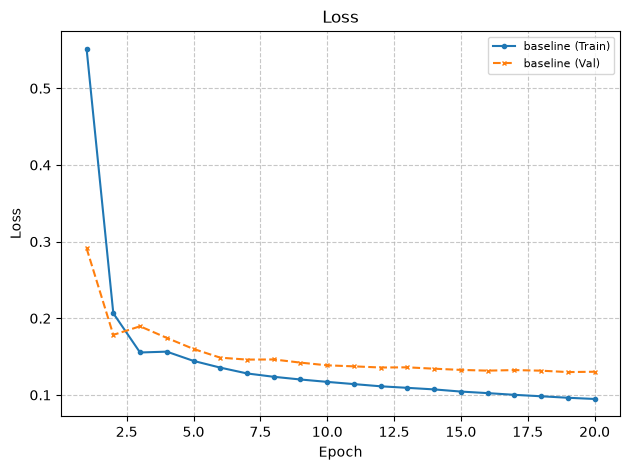

In [372]:
torch.manual_seed(67)
test_model = Task2BaselineHead(num_labels=len(LABELS), task1_model=final_task1_model).to(device)

optimizer = optim.Adam(test_model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss(reduction='none')

baseline_result = {}
baseline_result['baseline'] = run_experiment_task2(test_model, optimizer, criterion, 
                                     task2_train_loader, task2_val_loader, 
                                         epochs=20, name='Task2Baseline', load_best_model=False)

plot_experiments(baseline_result)

### Evaluating the Model:

Viewing the direct examples, I can see many large issues with the current model. 

1. The model rarely spans sequences of text. Instead most of its spans are one-token long. In these examples below, it creates one token length spans rather than the long span of text that the ground truth shows.

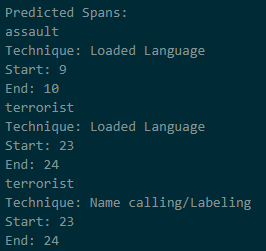

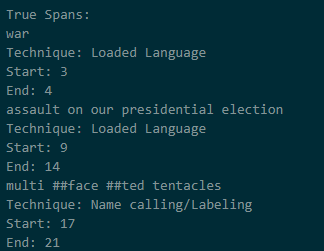

2. The model sometimes spans [PAD] tokens, even though these are usually out of the context of the meme and should not be happening.

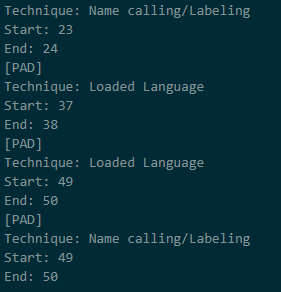

3. The model will sometimes either not predict for a flagged technique. E.g In this example, it does not even make any predictions, despite the flagged techniques.

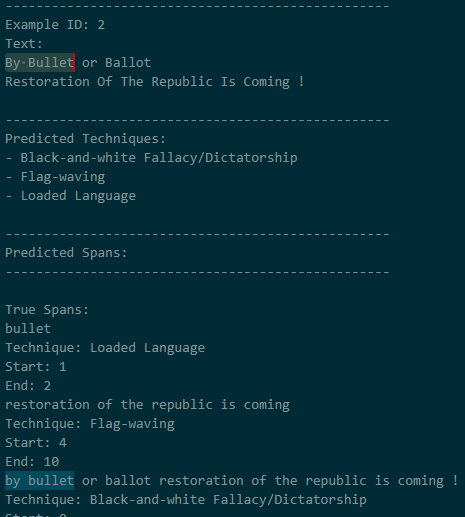

4. Or the model will predict for the wrong technique. E.g In this example, the model repeatedly makes spans for the "Whataboutisms" technique, despite it not being one of the flagged techniques. 

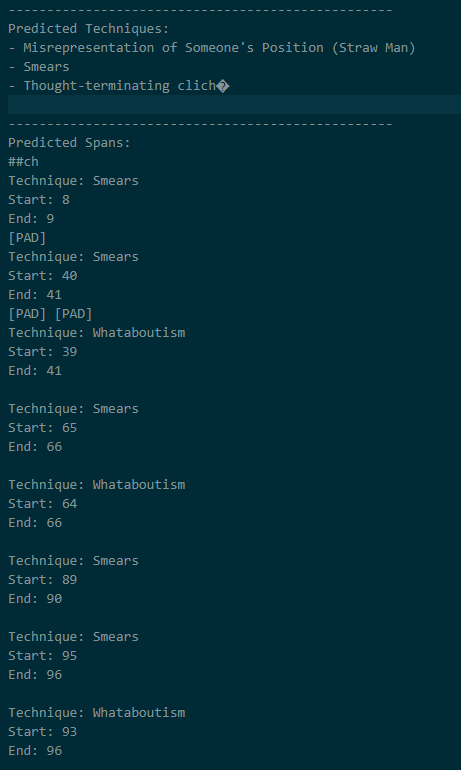
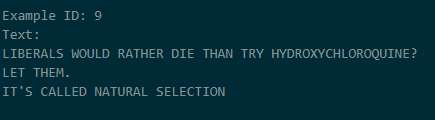

Because of these issues, this classifier head is completely unfit for the task.

In [373]:
metrics, examples = evaluate_task2(test_model, task2_test_loader)

for key in metrics:
    print(f"{key}: {metrics[key] :.3f}")

accuracy: 0.961
precision: 0.669
recall: 0.138
f1: 0.229
loss: 0.127


In [374]:
write_examples(examples, 
               "baseline.txt", 
               to_console=False, 
               skip_unflagged_labels=True)

### Improvement 1: Specialized Classifier Heads

One limitation of our baseline model is the fact that we have one generic classifier head to do spanning for every single technique. The head can then not be able to specialize into spanning for one specific technique, we expect that relying on one of two single weights to completely change how the model reacts. By instead changing the model so that we have multiple classifier heads and can choose which one to use for which technique, each head is able to specialize into its niche, and learning should improve. Furthermore, since we're only using the heads for techniques we predict are in the meme, it means that for other techniques, we will always have a completely empty span vector.

### Modifications to Functions


In [ ]:
def evaluate_task2(model, loader, num_examples=1):
    """
    Task 2 equivalent of evaluate_model from Task 1.
    Adapted for Experiments 2, by adjusting the loss function to account for multiple specialized heads.
    """
    
    model.eval()

    total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0
    total_loss, total = 0.0, 0
    examples = []

    with torch.inference_mode():
        for batch in loader:

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            spans = batch['spans'].to(device)
            techniques = batch['labels'].to(device)
            
            # Create a mask which masks out techniques which are not being used
            technique_mask = techniques.unsqueeze(1)

            logits = model(input_ids, attention_mask, techniques)

            # Get rid of the positions for [CLS] and [SEP]
            spans = spans[:, 1:-1, :]
            attention_mask = attention_mask[:, 1:-1]
            
            loss = criterion(logits, spans)

            mask = attention_mask.unsqueeze(-1)
            
            # Combine the technique and attention mask
            combined_mask = mask * technique_mask
            
            # Get the mean loss
            loss = (loss * combined_mask).sum() / combined_mask.expand_as(loss).sum()

            total_loss += loss.item() * input_ids.size(0)
            total += input_ids.size(0)

            # Creates probabilities and converts them to boolean signals
            probabilities = torch.sigmoid(logits)
            predicted_spans = probabilities >= 0.5

            # Calculate Metrics
            metric_mask = mask.bool()

            tp = predicted_spans & (spans == 1) & metric_mask
            fp = predicted_spans & (spans == 0) & metric_mask
            fn = (~predicted_spans) & (spans == 1) & metric_mask
            tn = (~predicted_spans) & (spans == 0) & metric_mask

            total_tp += tp.sum().item()
            total_fp += fp.sum().item()
            total_fn += fn.sum().item()
            total_tn += tn.sum().item()
        
        # Save examples
        for technique in LABELS:
            # Looks through our set of examples and saves model outputs to a dictionary
            example_set = task2_example_set[technique]
            for i in range(min(num_examples, len(example_set))):
                example = example_set[i]
                
                input_ids = example['input_ids'].unsqueeze(0).to(device)
                attention_mask = example['attention_mask'].unsqueeze(0).to(device)
                spans = example['spans'].unsqueeze(0).to(device)
                techniques = example['labels'].unsqueeze(0).to(device)
                lengths = torch.tensor([example['lengths']]).to(device)
                
                logits = model(input_ids, attention_mask, techniques)

                spans = spans[:, 1:-1, :]
                attention_mask = attention_mask[:, 1:-1]
                
                probabilities = torch.sigmoid(logits)
                predicted_spans = probabilities >= 0.5

                # Convert to lists for easier handling
                predicted_spans_list = predicted_spans.squeeze(0).cpu().numpy().tolist()
                true_spans_list = spans.squeeze(0).cpu().numpy().tolist()

                examples.append({
                    "text": example["text"],
                    "predicted_spans": predicted_spans_list,
                    "true_spans": true_spans_list,
                    "labels": techniques
                })

    # Calculate macro metrics for the model
    precision = total_tp / (total_tp + total_fp) if total_tp + total_fp > 0 else 0
    recall = total_tp / (total_tp + total_fn) if total_tp + total_fn > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0 else 0
    )
    accuracy = (
        (total_tp + total_tn) /
        (total_tp + total_fp + total_fn + total_tn)
        if total_tp + total_fp + total_fn + total_tn > 0 else 0
    )

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "loss": total_loss / total
    }

    return metrics, examples

### Building the Model:

In [376]:

class Task2SpecializedHeads(nn.Module):
    def __init__(self, num_labels, task1_model, hidden_dim=768):
        super().__init__()
        
        self.num_labels = num_labels
        self.distilbert = task1_model.distilbert
        
        for param in self.distilbert.parameters():
            param.requires_grad = False
        
        # Set of specialized heads that we can choose from for each technique. 
        self.heads = nn.ModuleList(
                                    nn.Sequential(
                                        nn.Dropout(0.2),
                                        nn.Linear(hidden_dim, 256),
                                        nn.ReLU(),
                                        nn.Linear(256, 1)
                                    )
            
                                    for label in range(num_labels)
                                )
    
    def forward(self, input_ids, attention_mask, techniques):
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        
        hidden_states = outputs.last_hidden_state
        
        # Remove [CLS] and [SEP] tokens
        hidden_states = hidden_states[:, 1:-1, :]
        
        # Initialize outputs to be by default negative.
        outputs = torch.full((hidden_states.size(0),
                                hidden_states.size(1),
                                self.num_labels),
                                -1e9).to(device)

        # Only edit the outputs corresponding to a technique we got in the input.
        for technique_index, head in enumerate(self.heads):
            active = techniques[:, technique_index].bool()
            
            if active.any():
                head_output = head(hidden_states[active])
                
                outputs[active, :, technique_index] = head_output.squeeze(-1)
        
        return outputs

  [SpecializedHeads] Epoch 1/20 — Train: 0.0596 | Val: 0.4917
  [SpecializedHeads] Epoch 4/20 — Train: 0.0410 | Val: 0.4446
  [SpecializedHeads] Epoch 8/20 — Train: 0.0332 | Val: 0.4378
  [SpecializedHeads] Epoch 12/20 — Train: 0.0286 | Val: 0.4542
  [SpecializedHeads] Epoch 16/20 — Train: 0.0254 | Val: 0.4690
  [SpecializedHeads] Epoch 20/20 — Train: 0.0226 | Val: 0.4810


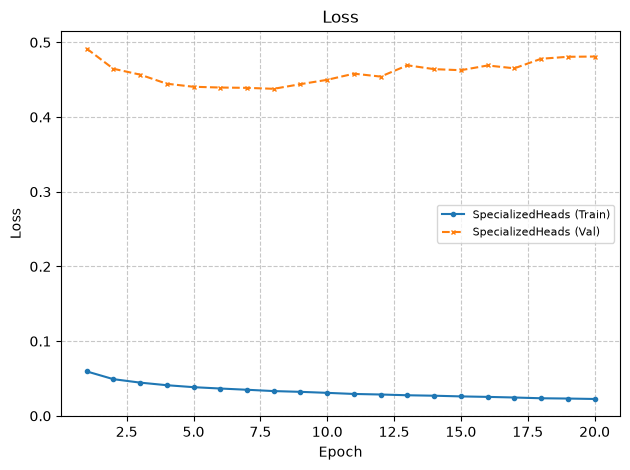

In [377]:
torch.manual_seed(67)
Task2SpecializedHead_Model = Task2SpecializedHeads(num_labels=len(LABELS), task1_model=final_task1_model).to(device)

optimizer = optim.Adam(Task2SpecializedHead_Model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss(reduction='none')
specializedhead_result = {}
specializedhead_result['SpecializedHeads'] = run_experiment_task2(Task2SpecializedHead_Model, optimizer, criterion,
                                                                  task2_train_loader, task2_val_loader,
                                                                  epochs=20, name="SpecializedHeads", load_best_model=False)

plot_experiments(specializedhead_result)

### Evaluating the Model:

The model immediately performs much better than the baseline. Just from its macro metrics, it has a much higher f1-score of 0.703 over the previous 0.230. Recall of 0.688 over 0.140 and precision of X over 0.655. 

Looking at the examples, I can see that we've almost completely solved the previous problems of:
1. One-token length spans. Now, spans are usually more than one token long. The same example of "assault", "war", etc. Gets spanned into "is a complex assault on"

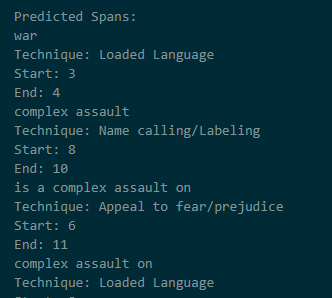

2. Predicting for the wrong technique. Because of our new architecture, it is now impossible for the model to create spanning predictions for techniques that we did not add to our input.

What is remaining are the problems of:

1. The model can still sometimes not span anything for a meme despite a technique being inputted. 

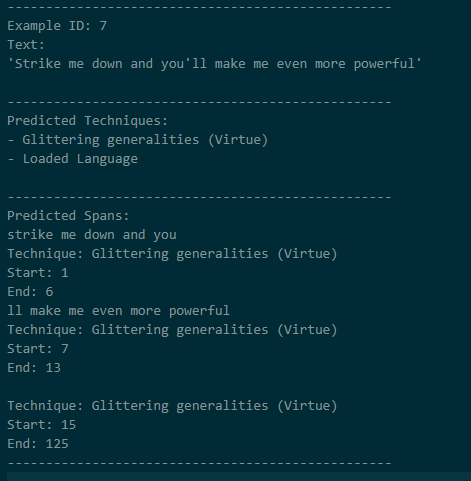

2. The model still spans out of bounds, creating spans in the [PAD] sections.

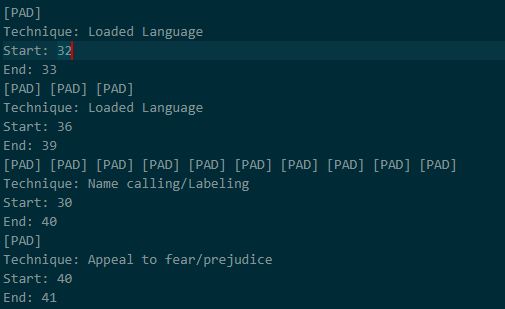

In [378]:
metrics, examples = evaluate_task2(Task2SpecializedHead_Model, task2_test_loader)

for key in metrics:
    print(f"{key}: {metrics[key] :.3f}")

accuracy: 0.977
precision: 0.715
recall: 0.728
f1: 0.721
loss: 0.610


In [379]:
write_examples(examples, 
               "Task2Specialized_Model.txt", 
               to_console=False, 
               skip_unflagged_labels=True)

### Improvement 2: Masking

The simplest solution that I can think of to solve the out of bounds issue is by simply creating a mask over the lengths of each meme and only allowing logits to be created within those bounds. This should not effect other model metrics, but just get rid of this lingering issue. To do this, I will need to get the length of each meme as an input for our model.

### Adjustments to Methods:

We need to adjust the following methods so that we pass in the length parameter to model when predicting. 

In [463]:
def evaluate_task2(model, loader, num_examples=1):
    """
    Task 2 equivalent of evaluate_model from Task 1.
    Adapted for Experiments 3, by passing new length parameter to model.
    """
    
    model.eval()

    total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0
    total_loss, total = 0.0, 0
    examples = []

    with torch.inference_mode():
        for batch in loader:

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            spans = batch['spans'].to(device)
            techniques = batch['labels'].to(device)
            lengths = batch['lengths'].to(device)
            
            # Create a mask which masks out techniques which are not being used
            technique_mask = techniques.unsqueeze(1)

            logits = model(input_ids, attention_mask, lengths, techniques)

            # Get rid of the positions for [CLS] and [SEP]
            spans = spans[:, 1:-1, :]
            attention_mask = attention_mask[:, 1:-1]
            
            loss = criterion(logits, spans)

            mask = attention_mask.unsqueeze(-1)
            
            # Combine the technique and attention mask
            combined_mask = mask * technique_mask
            
            # Get the mean loss
            loss = (loss * combined_mask).sum() / combined_mask.expand_as(loss).sum()

            total_loss += loss.item() * input_ids.size(0)
            total += input_ids.size(0)

            # Creates probabilities and converts them to boolean signals
            probabilities = torch.sigmoid(logits)
            predicted_spans = probabilities >= 0.5

            # Calculate Metrics
            metric_mask = mask.bool()

            tp = predicted_spans & (spans == 1) & metric_mask
            fp = predicted_spans & (spans == 0) & metric_mask
            fn = (~predicted_spans) & (spans == 1) & metric_mask
            tn = (~predicted_spans) & (spans == 0) & metric_mask

            total_tp += tp.sum().item()
            total_fp += fp.sum().item()
            total_fn += fn.sum().item()
            total_tn += tn.sum().item()
        
        # Save examples
        for technique in LABELS:
            # Looks through our set of examples and saves model outputs to a dictionary
            example_set = task2_example_set[technique]
            for i in range(min(num_examples, len(example_set))):
                example = example_set[i]
                
                input_ids = example['input_ids'].unsqueeze(0).to(device)
                attention_mask = example['attention_mask'].unsqueeze(0).to(device)
                spans = example['spans'].unsqueeze(0).to(device)
                techniques = example['labels'].unsqueeze(0).to(device)
                lengths = torch.tensor([example['lengths']]).to(device)
                
                logits = model(input_ids, attention_mask, lengths, techniques)

                spans = spans[:, 1:-1, :]
                attention_mask = attention_mask[:, 1:-1]
                
                probabilities = torch.sigmoid(logits)
                predicted_spans = probabilities >= 0.5

                # Convert to lists for easier handling
                predicted_spans_list = predicted_spans.squeeze(0).cpu().numpy().tolist()
                true_spans_list = spans.squeeze(0).cpu().numpy().tolist()

                examples.append({
                    "text": example["text"],
                    "predicted_spans": predicted_spans_list,
                    "true_spans": true_spans_list,
                    "labels": techniques
                })

    # Calculate macro metrics for the model
    precision = total_tp / (total_tp + total_fp) if total_tp + total_fp > 0 else 0
    recall = total_tp / (total_tp + total_fn) if total_tp + total_fn > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0 else 0
    )
    accuracy = (
        (total_tp + total_tn) /
        (total_tp + total_fp + total_fn + total_tn)
        if total_tp + total_fp + total_fn + total_tn > 0 else 0
    )

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "loss": total_loss / total
    }

    return metrics, examples

In [399]:
def train_one_epoch_task2(model, loader, optimizer, criterion):
    """
    Task 2 equivalent of train_one_epoch in Task 1. 
    Adapted for Experiment 3 by passing in the new parameter lengths into model.
    """
    model.train()
    
    total_loss, total = 0.0, 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        spans = batch['spans'].to(device)
        techniques = batch['labels'].to(device)
        lengths = batch['lengths'].to(device)
        
        # Create a mask which masks out techniques which are not being used
        technique_mask = techniques.unsqueeze(1)
        
        optimizer.zero_grad()
        
        logits = model(input_ids, attention_mask, lengths, techniques)
        
        # Get rid of positions for [CLS] and [SEP]
        spans = spans[:, 1:-1, :]
        attention_mask = attention_mask[:, 1:-1]
        
        loss = criterion(logits, spans)
        
        mask = attention_mask.unsqueeze(-1)
        
        # Combines the attention mask and technique mask
        mask = mask * technique_mask
        
        # Get the mean loss
        loss = (loss * mask).sum() / mask.expand_as(loss).sum()
        
        loss.backward()
        
        optimizer.step()
        
        total_loss += loss.item() * input_ids.size(0)
        total += input_ids.size(0)
    
    return total_loss / total

## Building the Model:

Building the model follows almost the exact same steps as before, but we just add 

In [382]:
class Task2SpecializedHeads_WithMasking(nn.Module):
    def __init__(self, num_labels, task1_model, hidden_dim=768):
        super().__init__()
        
        self.num_labels = num_labels
        self.distilbert = task1_model.distilbert
        
        for param in self.distilbert.parameters():
            param.requires_grad = False
        
        # Set of specialized heads that we can choose from for each technique. 
        self.heads = nn.ModuleList(
                                    nn.Sequential(
                                        nn.Dropout(0.2),
                                        nn.Linear(hidden_dim, 256),
                                        nn.ReLU(),
                                        nn.Linear(256, 1)
                                    )
            
                                    for label in range(num_labels)
                                )
    
    def forward(self, input_ids, attention_mask, lengths, techniques):
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        
        hidden_states = outputs.last_hidden_state
        
        # Remove [CLS] and [SEP] tokens
        hidden_states = hidden_states[:, 1:-1, :]
        
        # Initialize outputs to be by default negative.
        outputs = torch.full((hidden_states.size(0),
                                hidden_states.size(1),
                                self.num_labels),
                                -1e9).to(device)

        # Only edit the outputs corresponding to a technique we got in the input.
        for technique_index, head in enumerate(self.heads):
            active = techniques[:, technique_index].bool()
            
            if active.any():
                head_output = head(hidden_states[active])
                
                outputs[active, :, technique_index] = head_output.squeeze(-1)
        
        # Mask out the tokens which are out of bounds and set their values to be negative.
        token_positions = torch.arange(hidden_states.size(1)).to(device).unsqueeze(0)
        valid_mask = token_positions < lengths.unsqueeze(1)
        
        outputs = outputs.masked_fill(~valid_mask.unsqueeze(-1),
                                      -1e9)
        
        return outputs

### Training the Model:

  [Task2SpecializedHead] Epoch 1/20 — Train: 0.5649 | Val: 0.4783
  [Task2SpecializedHead] Epoch 4/20 — Train: 0.3915 | Val: 0.4245
  [Task2SpecializedHead] Epoch 8/20 — Train: 0.3096 | Val: 0.4314
  [Task2SpecializedHead] Epoch 12/20 — Train: 0.2652 | Val: 0.4477
  [Task2SpecializedHead] Epoch 16/20 — Train: 0.2341 | Val: 0.4631
  [Task2SpecializedHead] Epoch 20/20 — Train: 0.2113 | Val: 0.4752


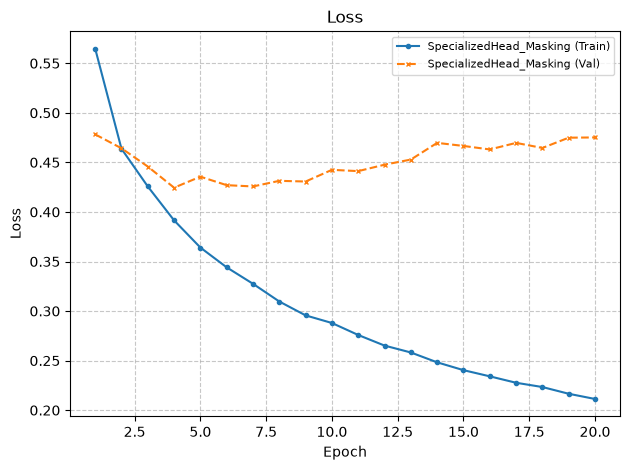

In [383]:
torch.manual_seed(67)
SpecializedHeadMasking = Task2SpecializedHeads_WithMasking(num_labels=len(LABELS), task1_model=final_task1_model).to(device)

optimizer = optim.Adam(SpecializedHeadMasking.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss(reduction='none')

SpecializedHeadMasking_Results = {}
SpecializedHeadMasking_Results['SpecializedHead_Masking'] = run_experiment_task2(SpecializedHeadMasking, optimizer, criterion, 
                                                        task2_train_loader, task2_val_loader, 
                                                        epochs=20, name='Task2SpecializedHead', load_best_model=False)

plot_experiments(SpecializedHeadMasking_Results, ["SpecializedHead_Masking"])

### Evaluating the Model:

Our overall metrics have not changed much compared to the one without masking. It only has minor improvements of around ~0.01 in precision, recall and f1. This is most likely due to the fact that the spans of [PAD] only make up a small percentage of the spanning predictions even without the masking. Examining the data, we can confirm that we have completely removed out of bound features within the predictions.

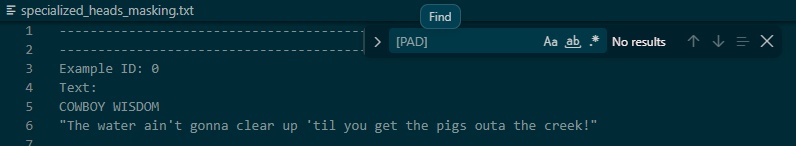

In [464]:
metrics, examples = evaluate_task2(SpecializedHeadMasking, task2_test_loader)

for key in metrics:
    print(f"{key}: {metrics[key] :.3f}")

accuracy: 0.977
precision: 0.721
recall: 0.736
f1: 0.728
loss: 0.602


In [494]:
write_examples(examples, "specialized_heads_masking.txt")

### Final Task 2 Classifier Evaluation

I decide that the model previously will be suitable for our Task 2 Classifier.

To clarify our naive benchmarks for the classifier were:

1. The classifier, when told that "X Technique is being used" WILL span a text as being the flagger.

2. The classifier will not span texts for techniques which we do not say are being part of its used techniques. E.g if the model flags a span of text as using technique Y when we tell it that Y is not being used in this meme, it is incorrect.

3. The classifier, given that it was inputted the correct techniques, should span at least one subsection contained within the actual span. E.g if a meme has spanned "This spans Loaded Language", the model should ideally create a span which contains at least some part of this span, like "spans Loaded Language". 

Our final classifier:

1. When told that "X technique is being used" MIGHT sometimes not span any text as being the flagger.

2. Will never span texts for techniques which we did not input it for. E.g if we did not tell the classifier that the meme uses technique Y, it will never create a span for technique Y.

3. Our classifier will most of the time span at least some subsection of the true span.

For benchmark 2, this is simply because of the architecture of how we decided to implement our classifier. Where it physically is unable to create these spans. 

For benchmark 3, a macro recall of 0.736, with a precision of 0.721 supports the contention that our model is able to flag spans of texts which contain at least some subset of the ground truth spans. Specifically, the precision of 0.721 also supports the idea that only some unneccessary sections were included in our spans, ~72% of the tokens within the predicted spans are part of the true spans. We can further confirm this by looking directly in the examples file, where most of the predicted spans in the examples seems to follow the pattern of what a "good" span is. 

For benchmark 1, this is admittedly a limitation of our model. Simply, there might be no way to actually ensure that the model will always create a span for a given technique. One idea that I was initially planning to counteract this was to change the way our model predicts, such that we would instead make the model predict two values, a start and an end position for each technique. This would ensure that we would at least have some span to create, however, with the existence of disjointed spans, i.e Loaded Language having two spans, (0,55), (68, 90). We might not be able to support these cases, which is why I did not choose to continue this.

We can study these examples where the model chooses not to create a span for a technique. 

In [429]:
task2_example_loader = DataLoader(task2_test_ds, batch_size=1, shuffle=False)

missing = []
total_spans = 0

SpecializedHeadMasking.eval()
for batch in task2_example_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    lengths = batch['lengths'].to(device)
    techniques = batch['labels'].to(device)
    texts = batch['text']
    
    with torch.no_grad():
        logits = SpecializedHeadMasking(input_ids, attention_mask, lengths, techniques)
        probabilities = torch.sigmoid(logits)
        predicted_spans = probabilities >= 0.5
    
    technique_present = torch.zeros((1,20))
    
    for technique_index, technique in enumerate(LABELS):
        if techniques[0, technique_index] == 1:
            total_spans += 1
            if not predicted_spans[0, :, technique_index].any().item():
                missing.append({"text": texts[0], "technique": technique})

print(f"Percent Missing: {100.0 * len(missing)/total_spans:.3f}%")

print("Printing example excerpts")
for missing_span in missing[:5]:
    print(f"Text:\n{missing_span["text"]}")
    print(f"Missing Technique: {missing_span["technique"]}")
    print()

Percent Missing: 8.060%
Printing example excerpts
Text:
I will never concede!

NO WAY IN HELL BIDEN WON!

Missing Technique: Loaded Language

Text:
'Strike me down and you'll make me even more powerful'
Missing Technique: Loaded Language

Text:
THE GOVERNMENT IS CORRUPT ON EVERY LEVEL BUT DON'T WORRY, THE GOVERNMENT WILL INVESTIGATE
ITSELF AND TELL YOU WHAT REALLY HAPPENED.

Missing Technique: Loaded Language

Text:
HAIL JUSTICE AMY CONEY-BARRETT

Missing Technique: Loaded Language

Text:
COWBOY WISDOM
"The water ain't gonna clear up 'til you get the pigs outa the creek!"

Missing Technique: Loaded Language



I believe that an 8% missing span rate is not too horrible for our task. Looking at some of the examples where a span was not able to be created, I as a human, sometimes struggle to create an exact span which is directly responsible for some technique. I believe that this is a fine limitation of our model, and later on in section C, I will continue to address this limitation.

## Whole Model

To create the whole model, I can just create a model which takes both the task 1 model and the task 2 classifier and just stick the former's output into the latter. 

### Baseline Whole Model

In [ ]:
class Task2WholeModel(nn.Module):
    def __init__(self, task1_model, task2_model, thresholds):
        super().__init__()
        
        # Freeze all parameters. We are no longer training
        for param in task1_model.parameters():
            param.requires_grad = False
        
        for param in task2_model.parameters():
            param.requires_grad = False
        
        self.task1_model = task1_model
        
        # Take just the specialized heads for task 2. 
        self.task2_heads = task2_model.heads
        
        # Take the thresholds that we computed from Task 1 so we can label each technique as positive or negative.
        self.thresholds = torch.tensor(thresholds, dtype=torch.float16)
    
    def forward(self, input_ids, attention_mask, lengths):
        self.task1_model.eval()
        self.task2_heads.eval()
        
        # Pass through task 1.
        with torch.no_grad():
            task1_outputs = self.task1_model(input_ids=input_ids, 
                                            attention_mask=attention_mask, 
                                            output_hidden_states=True)
        
        # Get the predicted techniques from task 1.
        task1_logits = task1_outputs.logits
        task1_probabilities = torch.sigmoid(task1_logits)
        techniques = task1_probabilities >= self.thresholds
        
        hidden_states = task1_outputs.hidden_states[-1]
        
        # Remove [CLS] and [SEP] tokens
        hidden_states = hidden_states[:, 1:-1, :]
        
        # Initialize outputs to be negative
        outputs = torch.full((hidden_states.size(0),
                                hidden_states.size(1),
                                len(LABELS)),
                                -1e9).to(device)

        # Only span for techniques we predict to be in the meme
        for technique_index, head in enumerate(self.task2_heads):
            active = techniques[:, technique_index].bool()
            
            if active.any():
                head_output = head(hidden_states[active])
                
                outputs[active, :, technique_index] = head_output.squeeze(-1)
        
        # Mask out all outputs for out of bound tokens.
        token_positions = torch.arange(hidden_states.size(1)).to(device).unsqueeze(0)
        valid_mask = token_positions < lengths.unsqueeze(1)
        
        outputs = outputs.masked_fill(~valid_mask.unsqueeze(-1),
                                      -1e9)
        
        return outputs

### Modify Functions



In [495]:
def evaluate_task2(model, loader, num_examples=1):
    """
    Task 2 equivalent of evaluate_model from Task 1.
    Adapted for the Final Model.
    """
    
    model.eval()

    total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0
    total_loss, total = 0.0, 0
    examples = []

    with torch.inference_mode():
        for batch in loader:

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            spans = batch['spans'].to(device)
            techniques = batch['labels'].to(device)
            lengths = batch['lengths'].to(device)
            
            # Create a mask which masks out techniques which are not being used
            technique_mask = techniques.unsqueeze(1)

            logits = model(input_ids, attention_mask, lengths)

            # Get rid of the positions for [CLS] and [SEP]
            spans = spans[:, 1:-1, :]
            attention_mask = attention_mask[:, 1:-1]
            
            loss = criterion(logits, spans)

            mask = attention_mask.unsqueeze(-1)
            
            # Combine the technique and attention mask
            combined_mask = mask * technique_mask
            
            # Get the mean loss
            loss = (loss * combined_mask).sum() / combined_mask.expand_as(loss).sum()

            total_loss += loss.item() * input_ids.size(0)
            total += input_ids.size(0)

            # Creates probabilities and converts them to boolean signals
            probabilities = torch.sigmoid(logits)
            predicted_spans = probabilities >= 0.5

            # Calculate Metrics
            metric_mask = mask.bool()

            tp = predicted_spans & (spans == 1) & metric_mask
            fp = predicted_spans & (spans == 0) & metric_mask
            fn = (~predicted_spans) & (spans == 1) & metric_mask
            tn = (~predicted_spans) & (spans == 0) & metric_mask

            total_tp += tp.sum().item()
            total_fp += fp.sum().item()
            total_fn += fn.sum().item()
            total_tn += tn.sum().item()
        
        # Save examples
        for technique in LABELS:
            # Looks through our set of examples and saves model outputs to a dictionary
            example_set = task2_example_set[technique]
            for i in range(min(num_examples, len(example_set))):
                example = example_set[i]
                
                input_ids = example['input_ids'].unsqueeze(0).to(device)
                attention_mask = example['attention_mask'].unsqueeze(0).to(device)
                spans = example['spans'].unsqueeze(0).to(device)
                techniques = example['labels'].unsqueeze(0).to(device)
                lengths = torch.tensor([example['lengths']]).to(device)
                
                logits = model(input_ids, attention_mask, lengths)

                spans = spans[:, 1:-1, :]
                attention_mask = attention_mask[:, 1:-1]
                
                probabilities = torch.sigmoid(logits)
                predicted_spans = probabilities >= 0.5

                # Convert to lists for easier handling
                predicted_spans_list = predicted_spans.squeeze(0).cpu().numpy().tolist()
                true_spans_list = spans.squeeze(0).cpu().numpy().tolist()

                examples.append({
                    "text": example["text"],
                    "predicted_spans": predicted_spans_list,
                    "true_spans": true_spans_list,
                    "labels": techniques
                })

    # Calculate macro metrics for the model
    precision = total_tp / (total_tp + total_fp) if total_tp + total_fp > 0 else 0
    recall = total_tp / (total_tp + total_fn) if total_tp + total_fn > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0 else 0
    )
    accuracy = (
        (total_tp + total_tn) /
        (total_tp + total_fp + total_fn + total_tn)
        if total_tp + total_fp + total_fn + total_tn > 0 else 0
    )

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    return metrics, examples

### Evaluating the Final Model:

As expected, we see a sharp decrease in all of our evaluation metrics. Unfortunately this is just the effect of having to rely on predicted techniques, rather than having the ground truth techniques being passed in. However, actually looking at the model's outputs for the examples, I notice that a lot of its reasonings are still interpretable despite not being accurate to those of the ground truths. I.e, even though the ground truth says a meme uses technique X, but our model predicts technique Y, the way that it spans for technique Y makes sense and is interpretable for me as a human.

One very good example of this lies here, although I agree that Doubt is still the most fitting technique to be used for this meme. I can understand why the model predicts Exaggeration/Minimisation, and its spans seems good where it supports that argument.

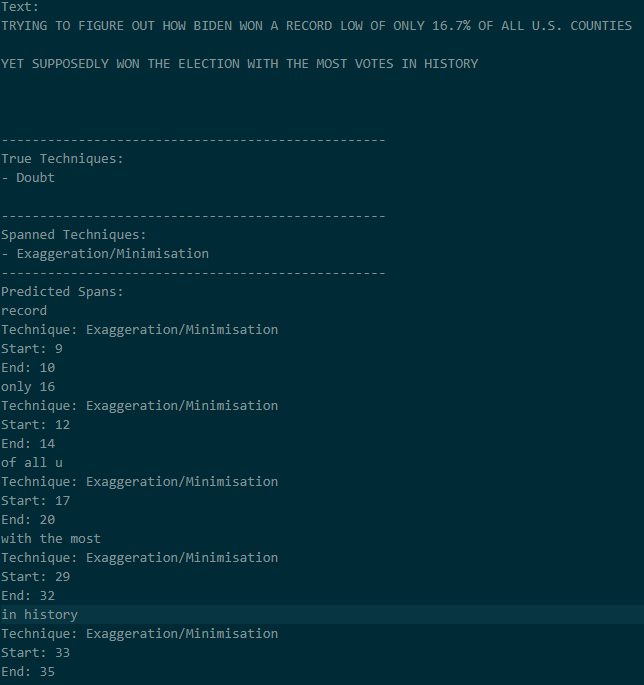

"only", "with the most", "in history" are all good examples of exaggeration/minimisation, and while it doesn't align with the ground truth according to the dataset, it is interpretable for a human. Because of this, I am satisfied with the model that we have, with the limitations that it has, and its strengths. I will continue to elaborate on these in Task C. 

In [ ]:
torch.manual_seed(67)
whole_model = Task2WholeModel(final_task1_model,
                                          SpecializedHeadMasking,
                                          THRESHOLDS)

metrics, examples = evaluate_task2(whole_model, task2_test_loader)

for key in metrics:
    print(f"{key}: {metrics[key] :.3f}")

accuracy: 0.887
precision: 0.147
recall: 0.358
f1: 0.209


In [497]:
write_examples(examples, "whole_baselines.txt", False)

# Task C

## C1. Does it treat all sides the same?

## C2. Defend the system you built.

## C3. Does the label head agree with the span head?

## C4. Will it work here? 